### **From Assignment # 01**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import os
import cv2
import nibabel as nib
import numpy as np

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# dataset folder
dataset = "/content/drive/MyDrive/group 10/group 10"

# folder for saving processed images
processed_folder = "/content/drive/MyDrive/Processed_MRI"
os.makedirs(processed_folder, exist_ok=True)

# getting all patient folders
patients = os.listdir(dataset)

# store metrics
psnr_scores = []
ssim_scores = []
results = []

# loop through patient folders
for patient in patients:

    patient_path = os.path.join(dataset, patient)

    # skip if not folder
    if not os.path.isdir(patient_path):
        continue

    # find t1c MRI
    mri_file = [
        f for f in os.listdir(patient_path)
        if "t1c" in f
    ][0]

    mri_path = os.path.join(
        patient_path,
        mri_file
    )

    # load MRI
    img = nib.load(mri_path)
    data = img.get_fdata()

    # middle slice
    middle = data.shape[2] // 2

    slice_img = data[:, :, middle]

    # normalize
    slice_img = cv2.normalize(
        slice_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # gaussian filter
    gaussian = cv2.GaussianBlur(
        slice_img,
        (5,5),
        0
    )

    # mean filter
    mean = cv2.blur(
        gaussian,
        (3,3)
    )

    # median filter
    median = cv2.medianBlur(
        mean,
        3
    )

    # anti aliasing
    anti_alias = cv2.GaussianBlur(
        median,
        (3,3),
        0
    )

    # downsampling
    resized = cv2.resize(
        anti_alias,
        (
            anti_alias.shape[1] // 2,
            anti_alias.shape[0] // 2
        )
    )

    # save processed image
    save_path = os.path.join(
        processed_folder,
        patient + ".png"
    )

    cv2.imwrite(
        save_path,
        resized
    )

    # resize original image for comparison
    slice_img_for_metrics = cv2.resize(
        slice_img,
        (
            resized.shape[1],
            resized.shape[0]
        ),
        interpolation=cv2.INTER_AREA
    )

    # PSNR
    psnr_value = peak_signal_noise_ratio(
        slice_img_for_metrics,
        resized
    )

    # SSIM
    ssim_value = structural_similarity(
        slice_img_for_metrics,
        resized,
        data_range=resized.max() - resized.min()
    )

    # store values
    psnr_scores.append(psnr_value)
    ssim_scores.append(ssim_value)

    results.append([
        patient,
        psnr_value,
        ssim_value
    ])

print("\nProcessed MRI Images Successfully")

# ==========================
# Individual Results
# ==========================

print("\nPatient\t\tPSNR\t\tSSIM")
print("-" * 50)

for patient, psnr, ssim in results:

    print(
        f"{patient}\t{psnr:.4f}\t{ssim:.4f}"
    )

# ==========================
# Average Results
# ==========================

avg_psnr = np.mean(psnr_scores)
avg_ssim = np.mean(ssim_scores)

print("\n" + "="*50)
print("AVERAGE RESULTS")
print("="*50)

print(f"Average PSNR : {avg_psnr:.4f}")
print(f"Average SSIM : {avg_ssim:.4f}")

# ==========================
# Bit Depth Analysis
# ==========================

print("\nBit Depth Analysis")

print(
    "Original dtype:",
    data.dtype
)

print(
    "Processed dtype:",
    resized.dtype
)

print(
    "Bit Depth:",
    resized.dtype.itemsize * 8
)


Processed MRI Images Successfully

Patient		PSNR		SSIM
--------------------------------------------------
BraTS-PED-00246-000	30.2915	0.9263
BraTS-PED-00251-000	29.1185	0.9318
BraTS-PED-00245-000	29.2939	0.9257
BraTS-PED-00241-000	29.6452	0.9206
BraTS-PED-00244-000	30.6722	0.9240
BraTS-PED-00243-000	27.8790	0.9089
BraTS-PED-00242-000	30.0133	0.9136
BraTS-PED-00248-000	29.2737	0.9058
BraTS-PED-00239-000	32.4299	0.9406
BraTS-PED-00247-000	31.0480	0.9500
BraTS-PED-00240-000	30.9236	0.9223
BraTS-PED-00238-000	30.8045	0.9323
BraTS-PED-00236-000	30.2640	0.9476
BraTS-PED-00249-000	29.4817	0.9382
BraTS-PED-00237-000	32.6923	0.9224
BraTS-PED-00235-000	29.7564	0.9204
BraTS-PED-00230-000	31.9374	0.9565
BraTS-PED-00233-000	29.6675	0.9148
BraTS-PED-00226-000	35.4371	0.9604
BraTS-PED-00234-000	28.9647	0.9122
BraTS-PED-00227-000	37.5690	0.9607
BraTS-PED-00231-000	29.0856	0.9246
BraTS-PED-00228-000	32.4063	0.9261
BraTS-PED-00232-000	29.3731	0.8954
BraTS-PED-00229-000	31.9383	0.9308

AVERAGE RESULTS
A

### **From Assignment # 02**


Processing: BraTS-PED-00246-000
Best Slice: 34

Chain Code:
[5, 4, 5, 5, 5, 4, 5, 5, 6, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 7, 7, 6, 7, 7, 0, 7, 7, 7, 7, 6, 7, 6, 7]

First Difference:
[7, 1, 0, 0, 7, 1, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 0, 7, 1, 0, 1, 7, 0, 0, 0, 7, 1, 7, 1, 1]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 1, 7, 1, 0, 0, 7, 0, 0, 0, 0, 1, 1, 7, 1, 0, 0, 0, 0, 0, 7, 1, 0, 0, 0, 2, 7, 0, 7, 1, 7, 0, 0, 0, 0, 1, 7, 0, 1, 7]


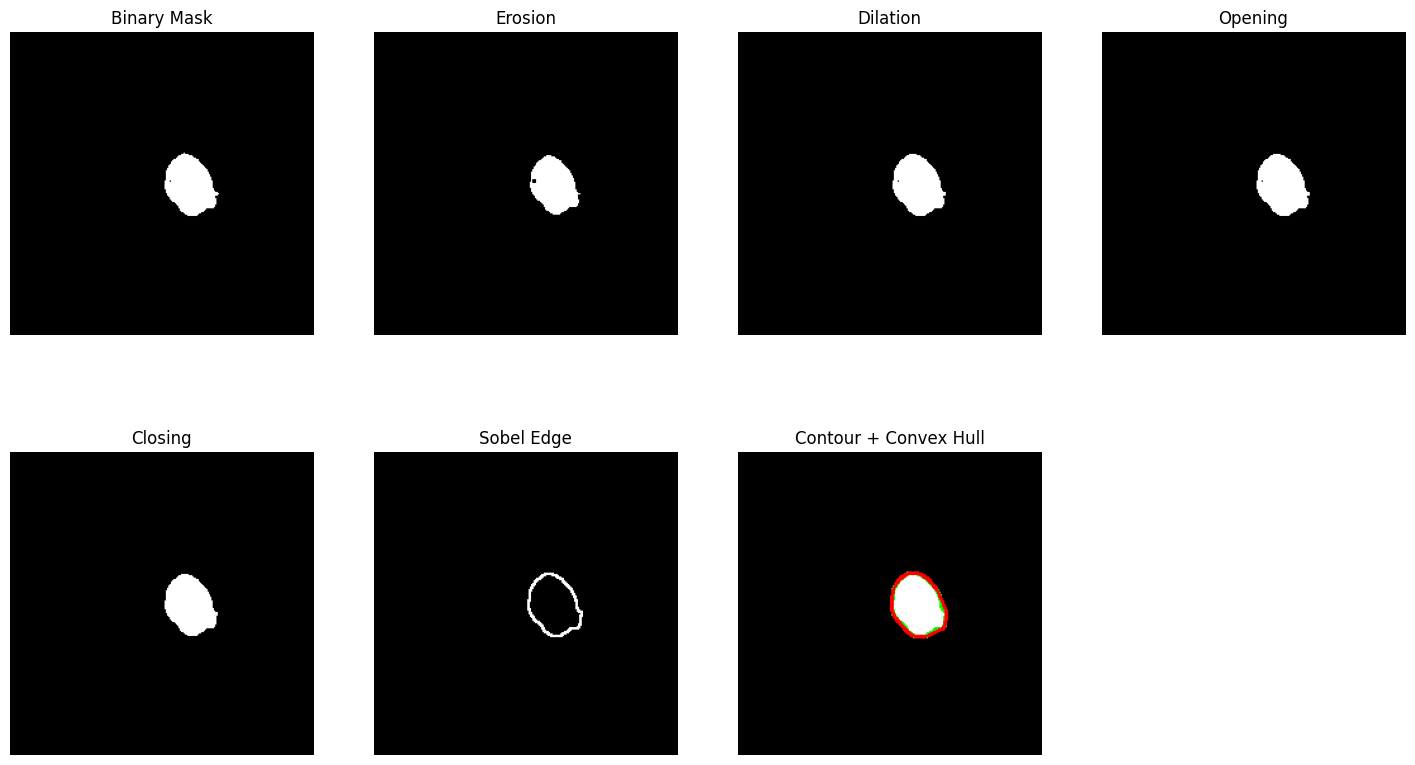

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00246-000_result.png

Processing: BraTS-PED-00251-000
Best Slice: 33

Chain Code:
[5, 4, 5, 6, 6, 6, 5, 6, 6, 6, 5, 5, 5, 4, 5, 5, 6, 6, 6, 6, 7, 6, 7, 7, 6, 7, 7, 7, 7, 7, 7, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 0, 1]

First Difference:
[7, 1, 1, 0, 0, 7, 1, 0, 0, 7, 0, 0, 7, 1, 0, 1, 0, 0, 0, 1, 7, 1, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 1, 1, 7, 7, 1, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 7, 1, 7, 1, 0, 0, 7, 1, 1, 0, 0, 7, 1, 0, 0, 7, 0, 0, 7, 1, 0, 1, 0, 0, 0, 1, 7]


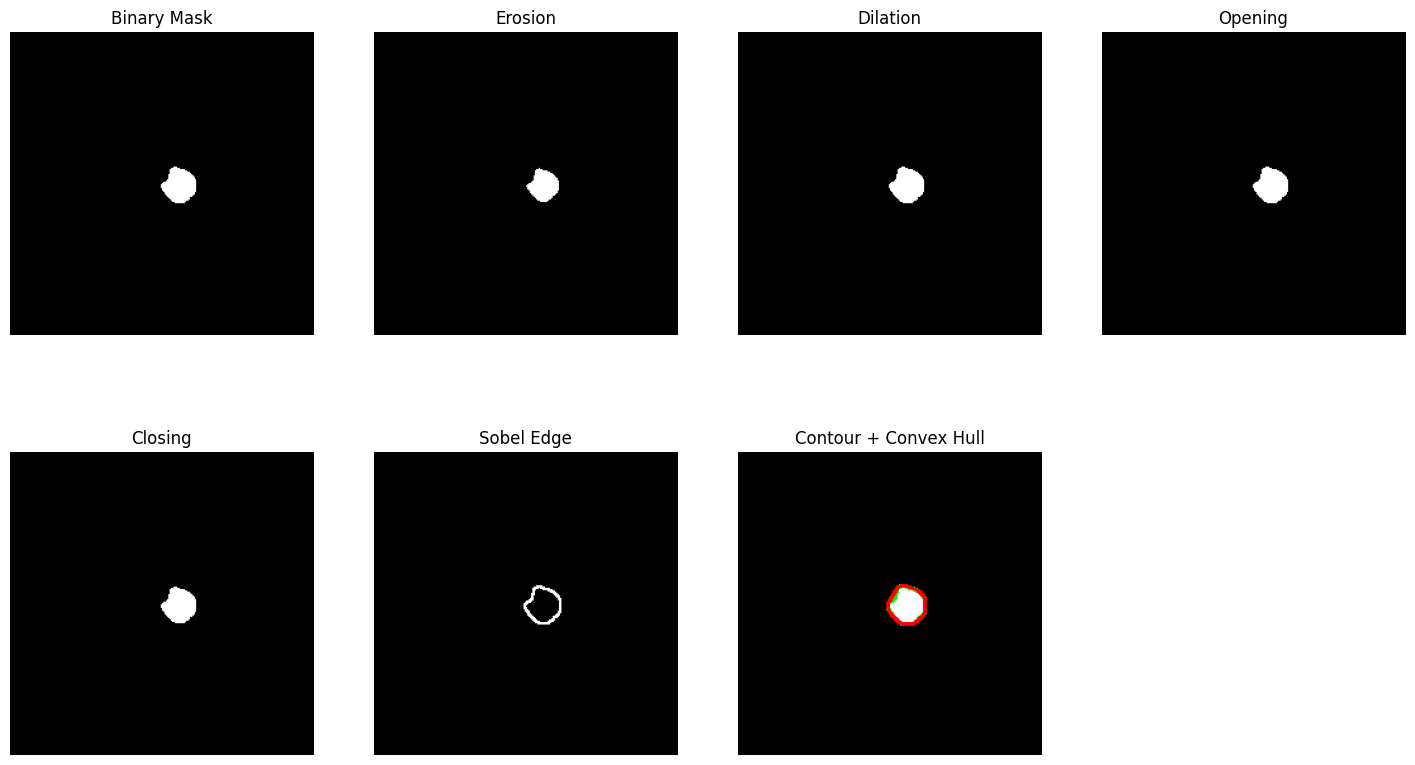

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00251-000_result.png

Processing: BraTS-PED-00245-000
Best Slice: 42

Chain Code:
[5, 4, 4, 4, 4, 4, 5, 4, 5, 5, 4, 5, 5, 4, 5, 5, 5, 5, 6, 5, 5, 6, 6, 6, 6, 6, 6, 0, 7, 6, 0, 7, 6, 5, 4, 4, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 7]

First Difference:
[7, 0, 0, 0, 0, 1, 7, 1, 0, 7, 1, 0, 7, 1, 0, 0, 0, 1, 7, 0, 1, 0, 0, 0, 0, 0, 2, 7, 7, 2, 7, 7, 7, 7, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 7, 1, 0, 0, 0, 1, 0, 7, 1, 0, 0, 7, 0, 0, 0, 0, 1, 7, 1, 0, 7, 1, 0, 7, 1]


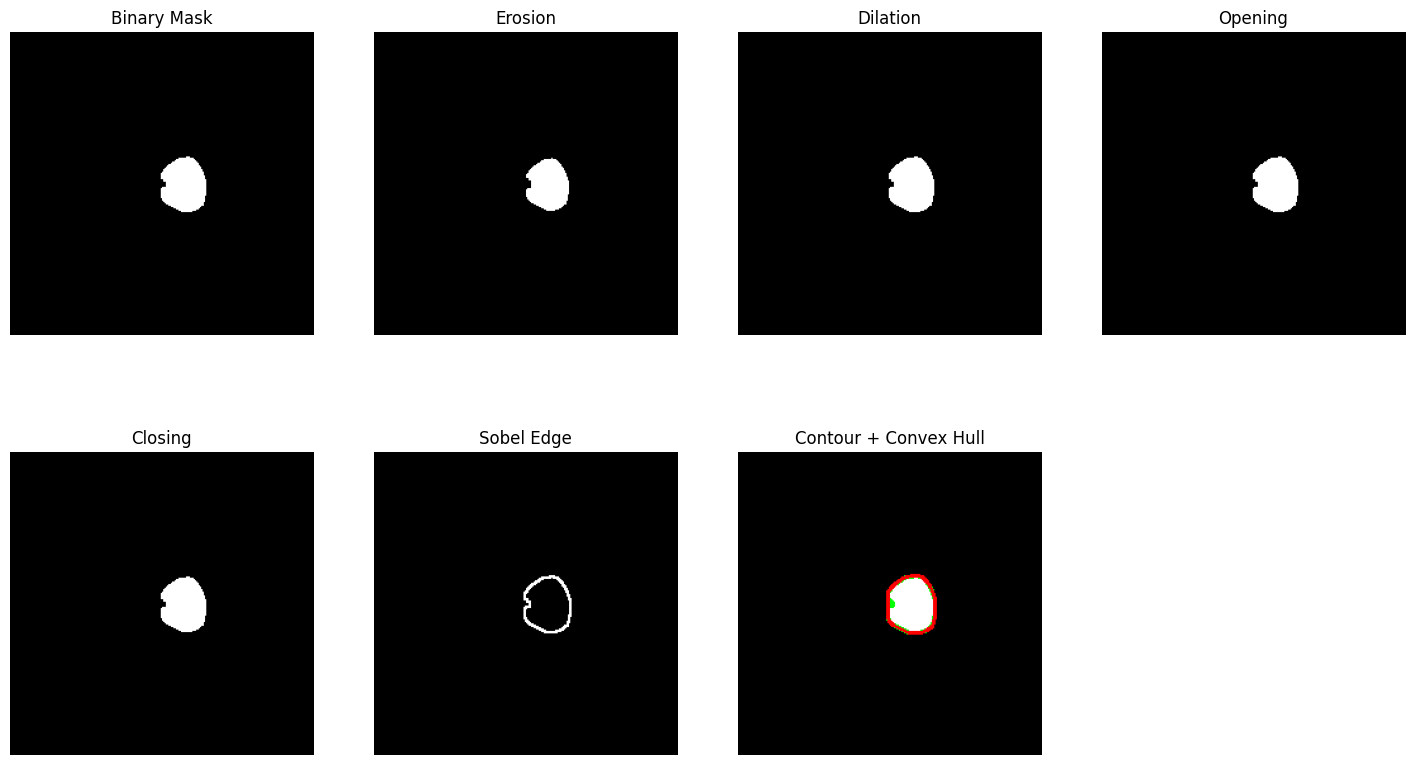

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00245-000_result.png

Processing: BraTS-PED-00241-000
Best Slice: 37

Chain Code:
[5, 4, 4, 5, 5, 4, 5, 5, 4, 5, 5, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 7, 0, 7, 5, 5, 4, 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 6, 7, 7]

First Difference:
[7, 0, 1, 0, 7, 1, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 7, 1, 7, 6, 0, 7, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 1, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 7, 0, 1, 1, 0, 7, 1, 7, 1, 7, 1]


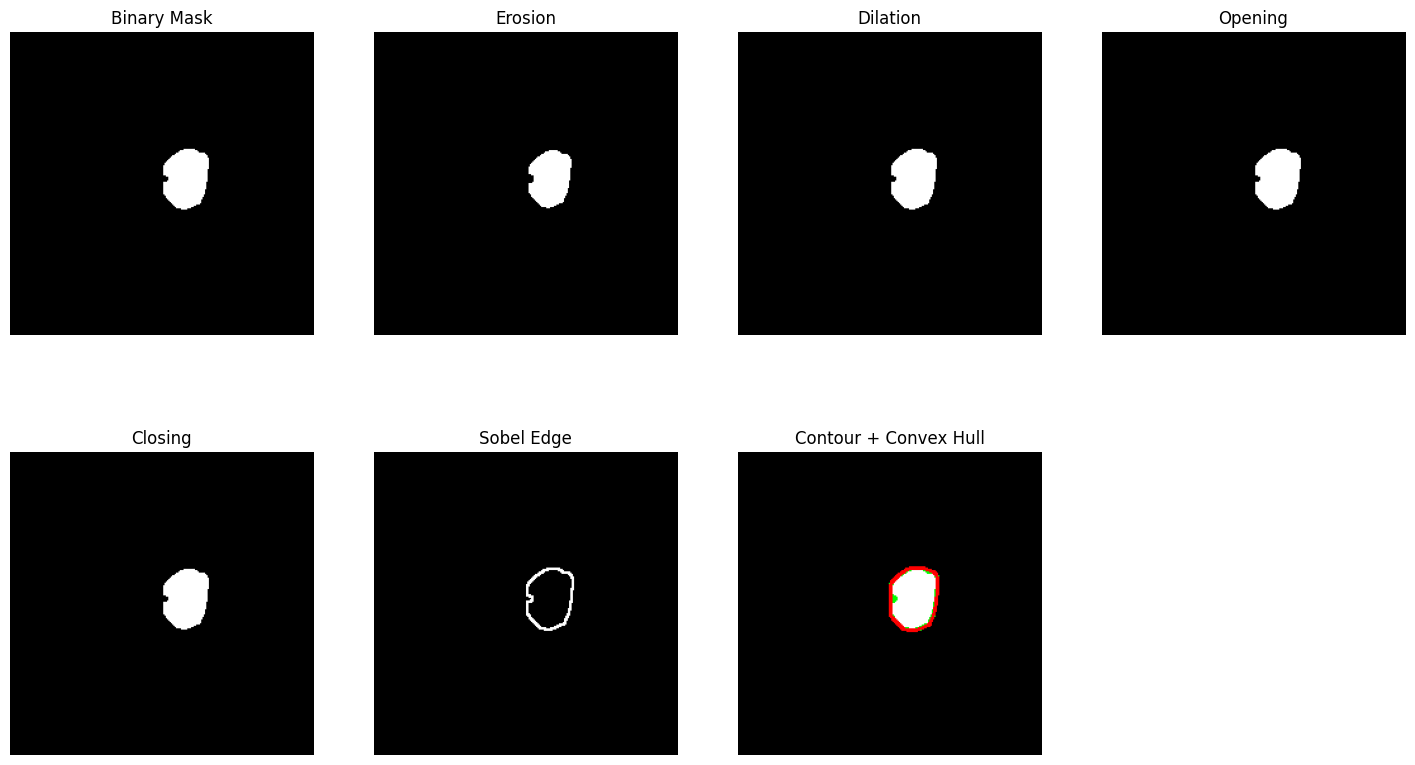

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00241-000_result.png

Processing: BraTS-PED-00244-000
Best Slice: 36

Chain Code:
[5, 4, 4, 5, 4, 5, 5, 4, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 6, 5, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 7, 0, 7, 7, 6, 5, 5, 5, 4, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7]

First Difference:
[7, 0, 1, 7, 1, 0, 7, 1, 0, 0, 0, 0, 7, 1, 0, 0, 0, 1, 7, 1, 0, 7, 1, 0, 0, 0, 0, 1, 7, 1, 1, 7, 0, 7, 7, 0, 0, 7, 2, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 0, 1, 7, 1, 0, 7, 0, 7, 1, 0, 1, 7, 1, 0, 7, 0, 1, 0, 7, 1]


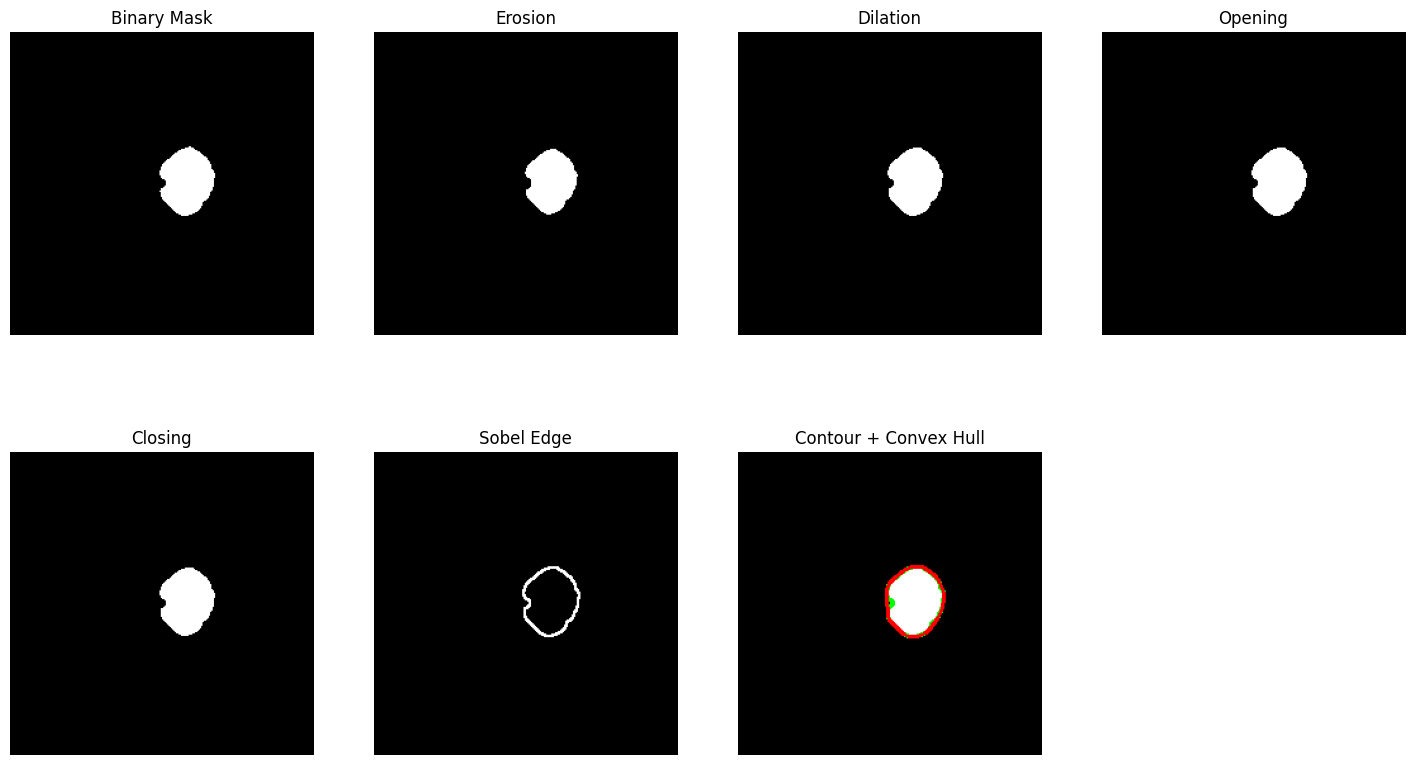

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00244-000_result.png

Processing: BraTS-PED-00243-000
Best Slice: 34

Chain Code:
[5, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 7, 5, 4, 4, 4, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 6, 7, 7, 7, 7, 7, 7]

First Difference:
[7, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 7, 6, 7, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 7, 6, 7, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 7, 1, 0]


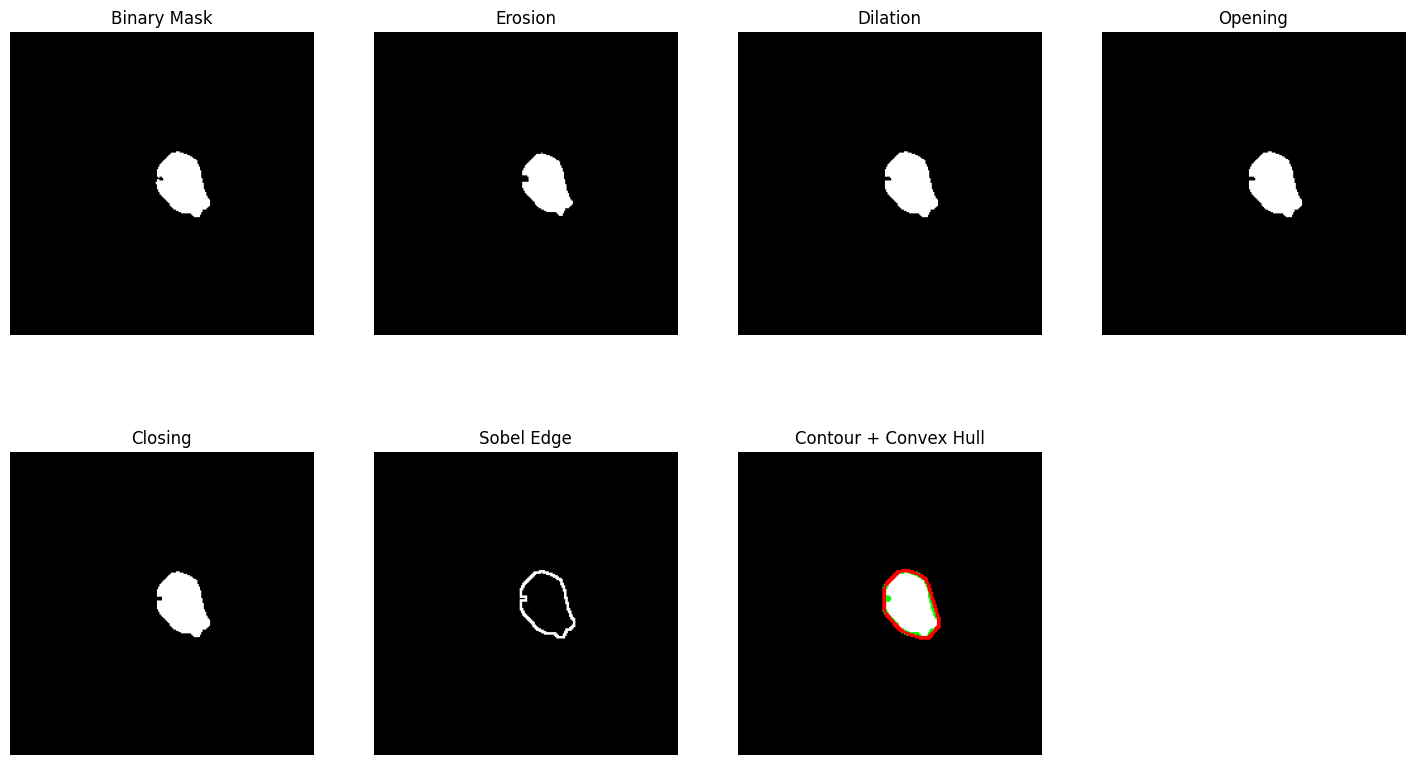

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00243-000_result.png

Processing: BraTS-PED-00242-000
Best Slice: 32

Chain Code:
[5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 0, 7, 0, 0, 0, 0, 0, 0, 0, 1, 0]

First Difference:
[7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 1, 7, 1, 1, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 1]


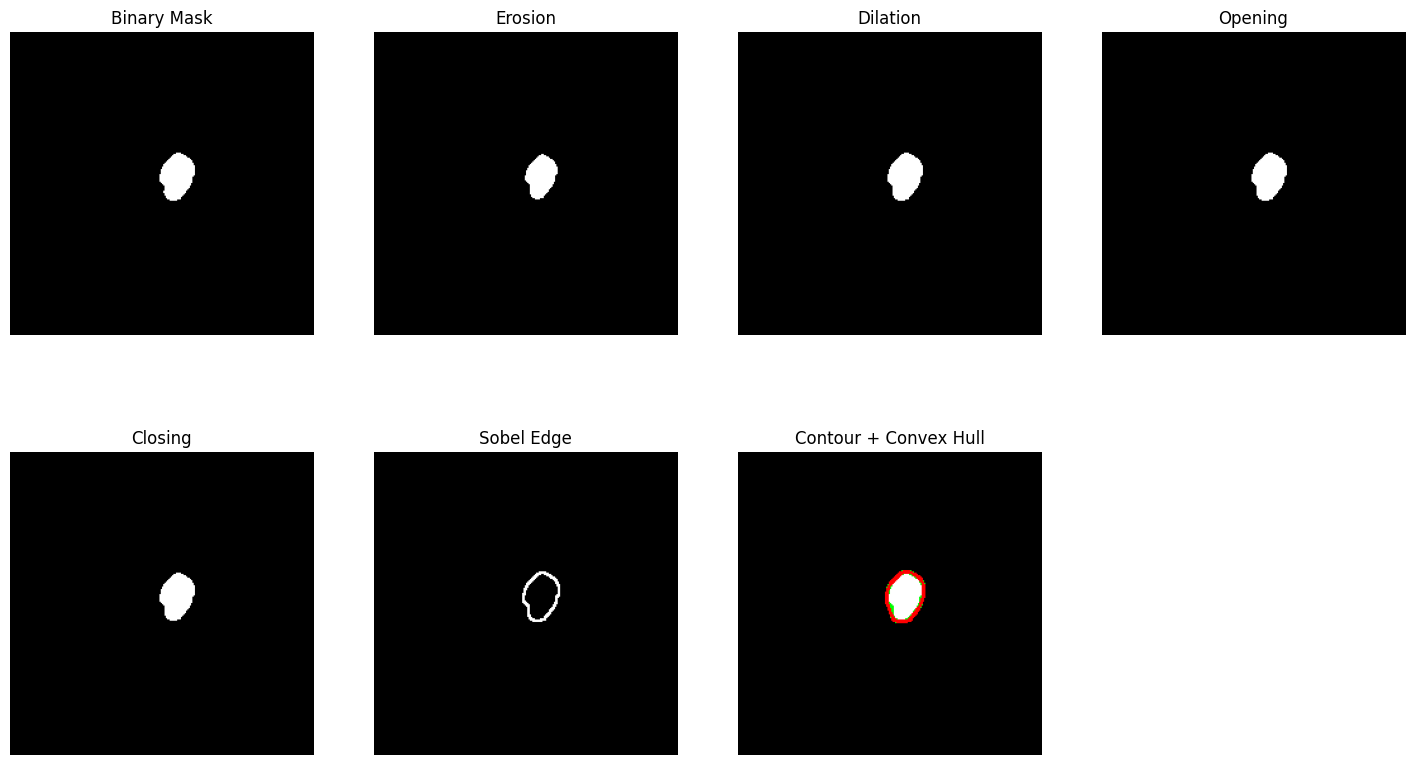

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00242-000_result.png

Processing: BraTS-PED-00248-000
Best Slice: 39

Chain Code:
[5, 5, 4, 5, 5, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 0, 0, 7, 7, 5, 5, 6, 6, 6, 6, 7, 6, 7, 7, 7, 0, 7, 0, 0, 0, 7, 0, 0]

First Difference:
[0, 7, 1, 0, 0, 1, 7, 1, 7, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 7, 0, 6, 0, 1, 0, 0, 0, 1, 7, 1, 0, 0, 1, 7, 1, 0, 0, 7, 1, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 1, 7, 0, 1, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 1, 0, 0, 1, 7, 1, 7, 0, 0]


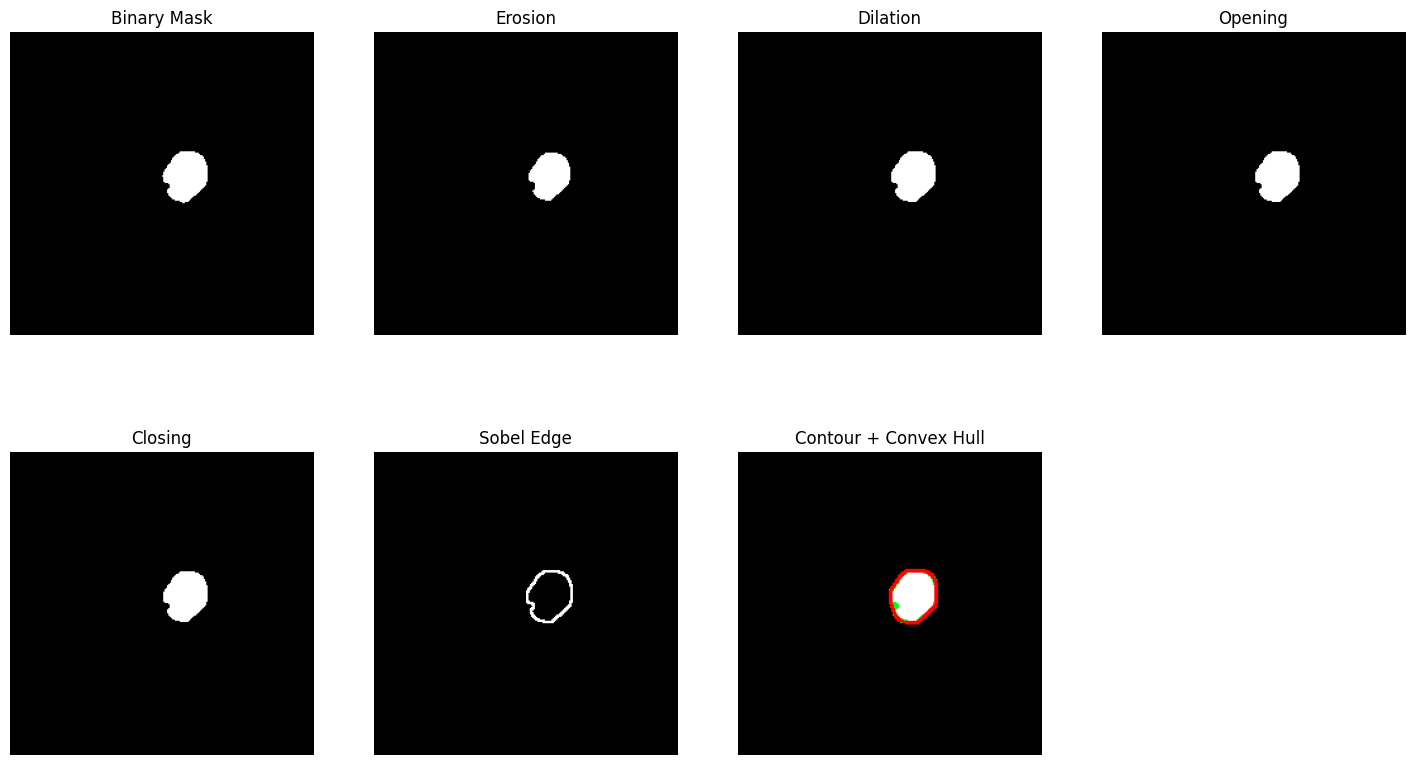

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00248-000_result.png

Processing: BraTS-PED-00239-000
Best Slice: 25

Chain Code:
[5, 4, 5, 5, 4, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 6, 6, 6, 7, 6, 0, 7, 5, 4, 4, 4, 4, 4, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 7, 6, 7, 7, 7]

First Difference:
[7, 1, 0, 7, 1, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 0, 0, 1, 7, 2, 7, 6, 7, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 0, 7]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 2, 0, 0, 0, 0, 7, 7, 0, 0, 0, 1, 0, 0, 0, 1, 7, 1, 7, 0, 1, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 7, 0, 7, 1]


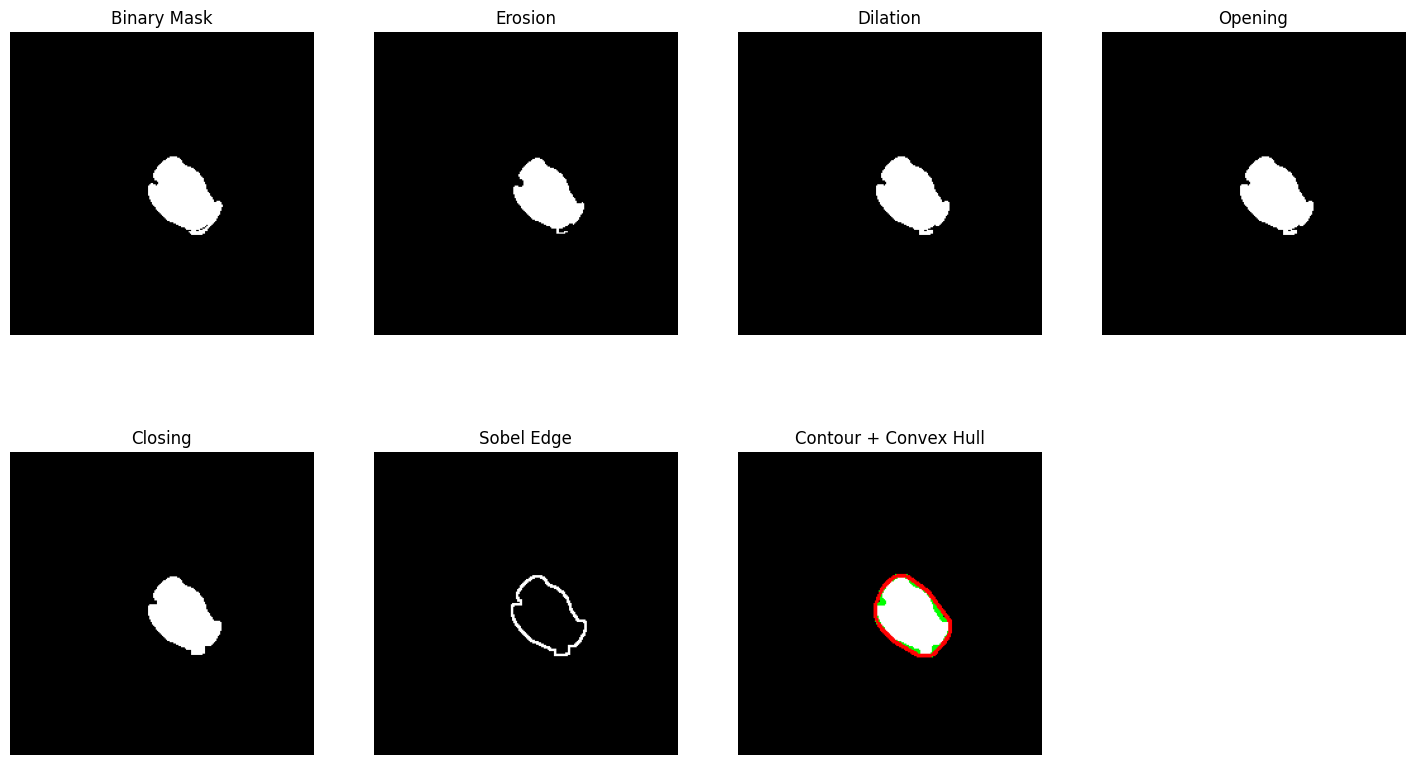

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00239-000_result.png

Processing: BraTS-PED-00247-000
Best Slice: 63

Chain Code:
[5, 4, 5, 4, 4, 5, 4, 5, 5, 5, 5, 5, 4, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 7, 7, 7, 0, 7, 0, 7, 0, 0, 7, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0]

First Difference:
[7, 1, 7, 0, 1, 7, 1, 0, 0, 0, 0, 7, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 1, 7, 1, 7, 1, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 1, 7, 1, 7, 1, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 1, 7, 1, 0, 0, 0, 1, 1, 7, 7, 1, 7]


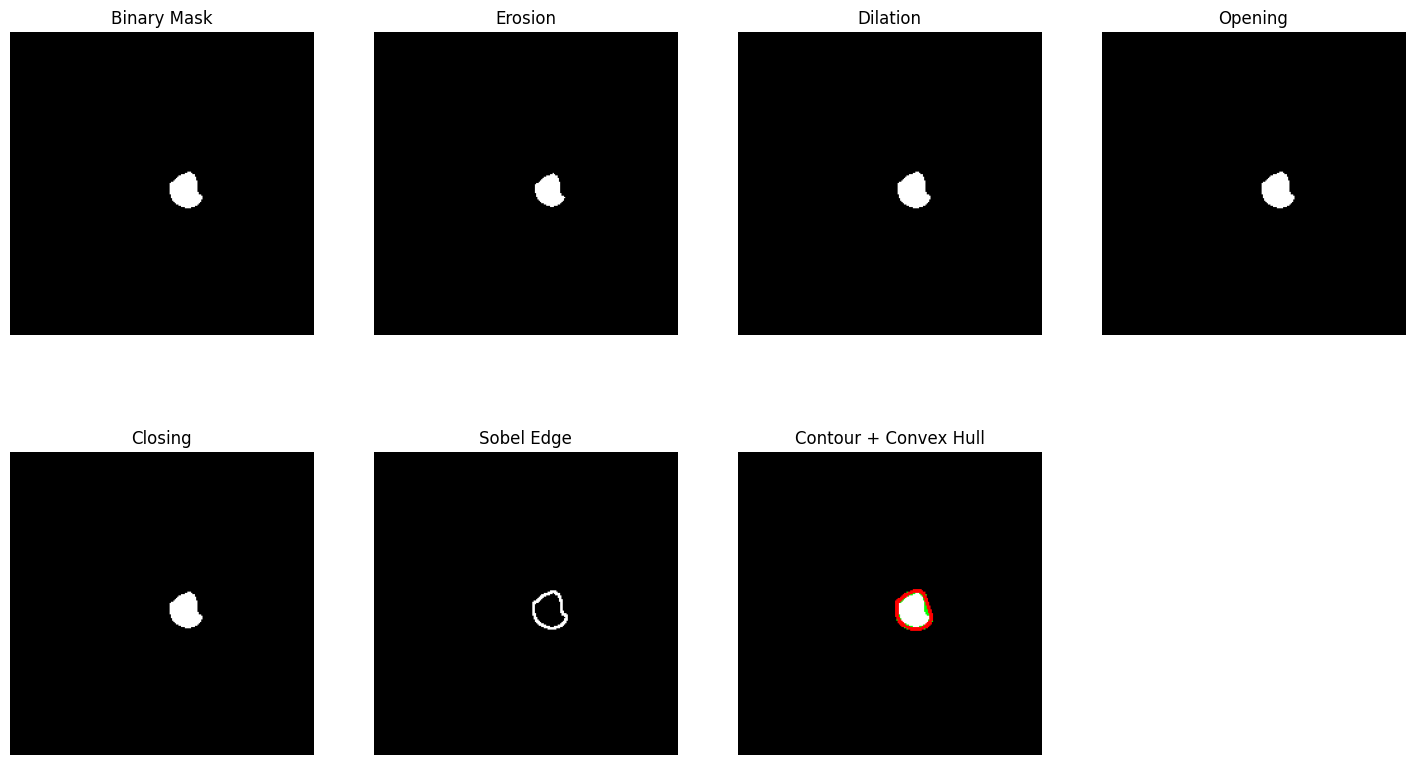

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00247-000_result.png

Processing: BraTS-PED-00240-000
Best Slice: 52

Chain Code:
[6, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 6, 6, 6, 6, 5, 4, 5, 4, 4, 5, 4, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 6, 7, 0, 0, 7]

First Difference:
[7, 1, 7, 0, 0, 0, 0, 0, 0, 0, 0, 7, 1, 0, 1, 0, 0, 0, 7, 7, 1, 7, 0, 1, 7, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 1, 1, 0, 7, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 1, 1, 0, 7, 0, 0, 0, 7, 1, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 7, 1, 0, 7, 1]


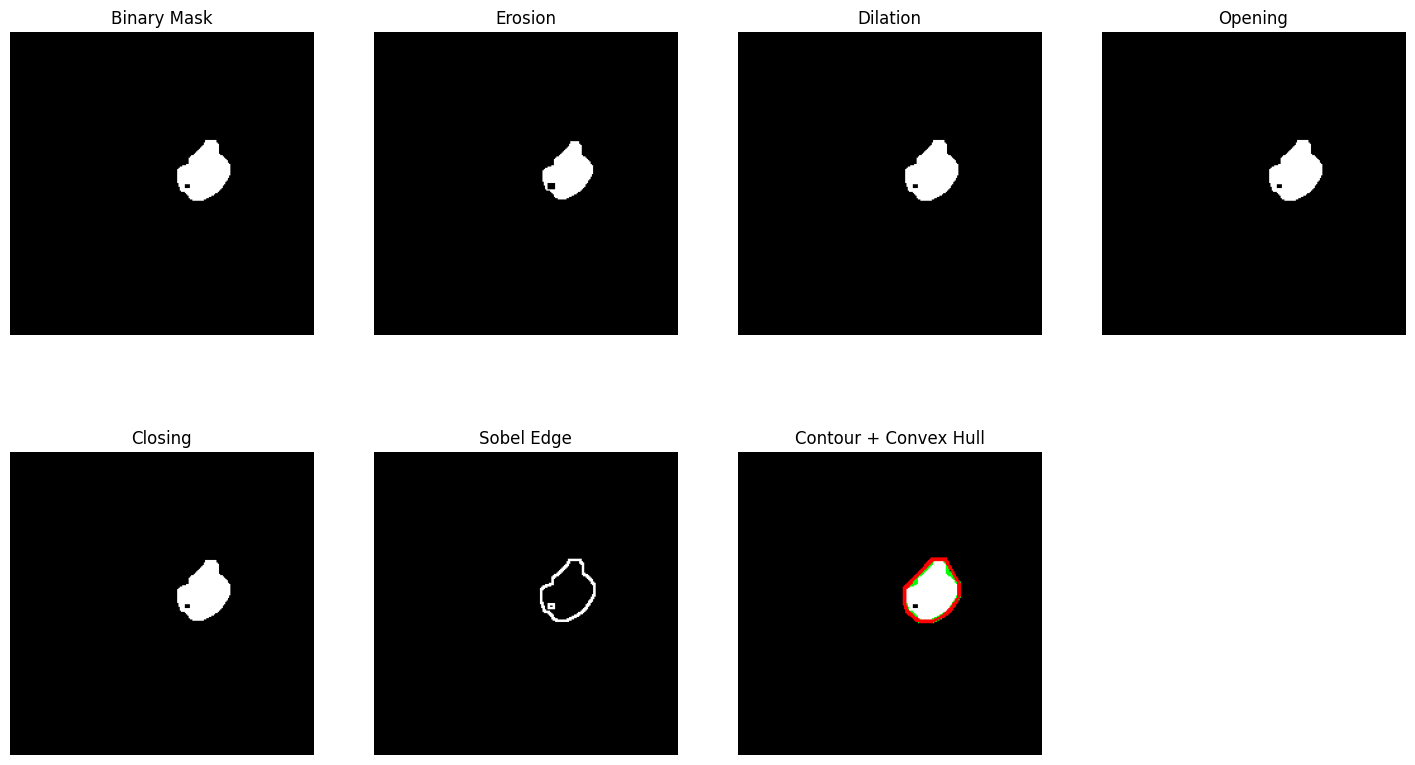

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00240-000_result.png

Processing: BraTS-PED-00238-000
Best Slice: 43

Chain Code:
[5, 4, 5, 4, 5, 4, 5, 6, 5, 6, 5, 5, 4, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 6, 6, 7, 7, 7, 7, 0, 7, 7, 0, 7, 0, 7, 0, 7, 7, 0]

First Difference:
[7, 1, 7, 1, 7, 1, 1, 7, 1, 7, 0, 7, 1, 1, 0, 7, 1, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 0, 1, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 7, 0, 1, 7]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 0, 1, 7, 0, 1, 7, 1, 0, 1, 7, 0, 1, 7, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 0, 0, 1, 0, 0, 0, 7, 1, 7, 1, 7, 1, 1, 7, 1, 7]


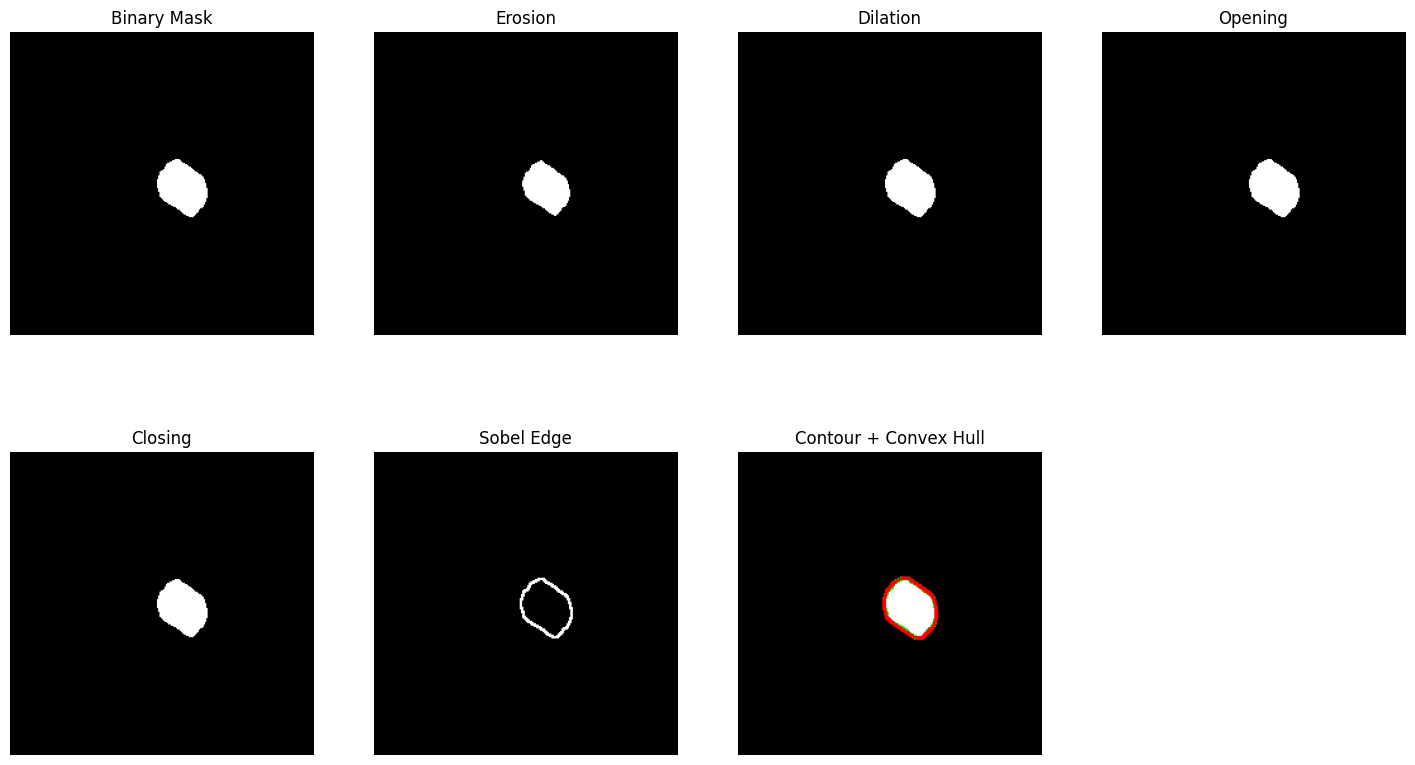

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00238-000_result.png

Processing: BraTS-PED-00236-000
Best Slice: 38

Chain Code:
[5, 4, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 7, 0, 0, 0, 7, 5, 4, 5, 6, 6, 6, 6, 7, 6, 6, 7, 7, 6, 7, 6, 7, 0, 7]

First Difference:
[7, 1, 0, 0, 0, 7, 1, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 7, 6, 7, 1, 1, 0, 0, 0, 1, 7, 0, 1, 0, 7, 1, 7, 1, 1, 7, 1]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 0, 0, 0, 1, 7, 0, 0, 0, 7, 1, 0, 0, 1, 7, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 7, 1, 0, 0, 0, 7, 1, 0, 0, 0, 0, 1, 7, 1]


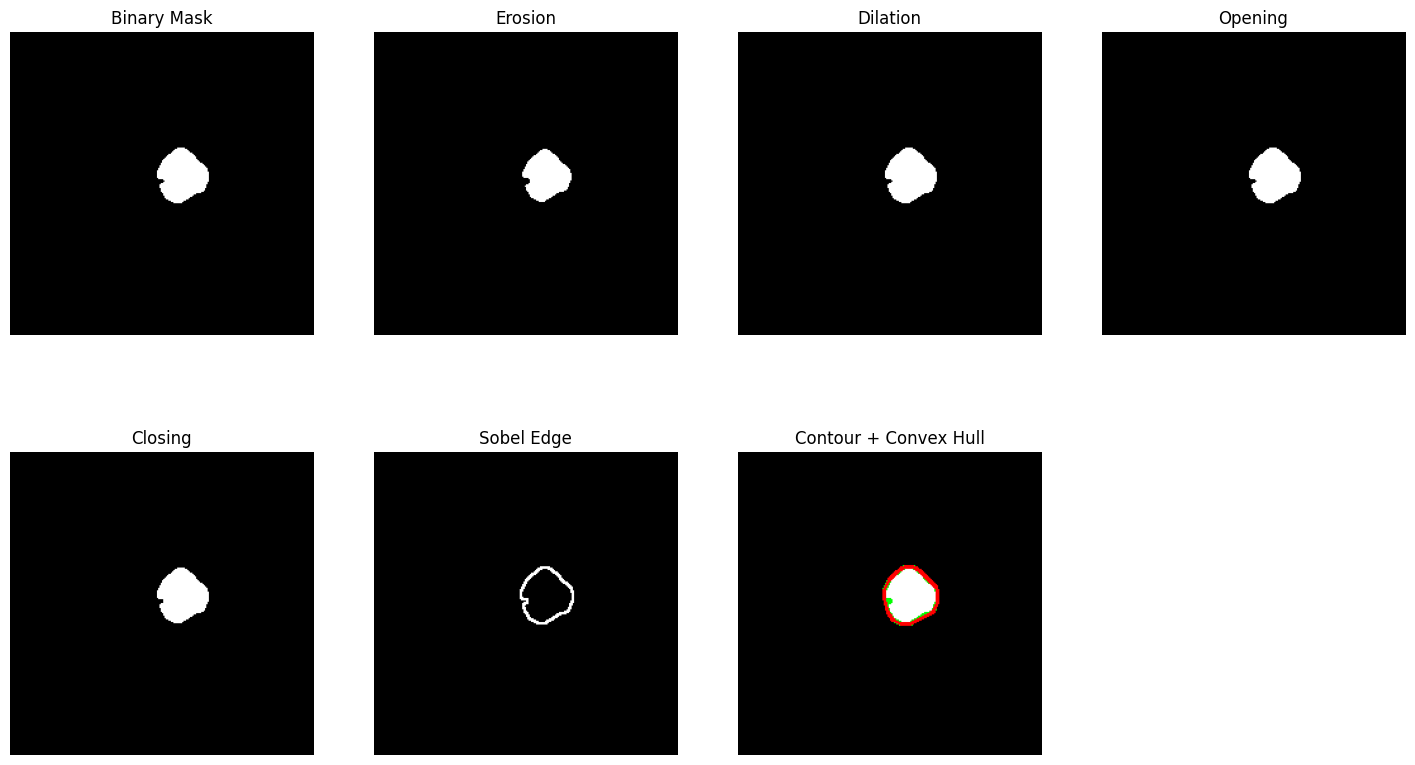

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00236-000_result.png

Processing: BraTS-PED-00249-000
Best Slice: 43

Chain Code:
[5, 5, 4, 5, 4, 5, 5, 4, 4, 5, 4, 5, 5, 5, 4, 5, 6, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 0, 0, 7, 0, 0, 7, 5, 4, 5, 4, 4, 5, 6, 6, 6, 6, 6, 6, 6, 7]

First Difference:
[0, 7, 1, 7, 1, 0, 7, 0, 1, 7, 1, 0, 0, 7, 1, 1, 7, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 2, 0, 7, 1, 0, 7, 6, 7, 1, 7, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 1, 7, 1, 1, 7, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 7, 1, 7, 1, 0, 7, 0, 1, 7, 1, 0]


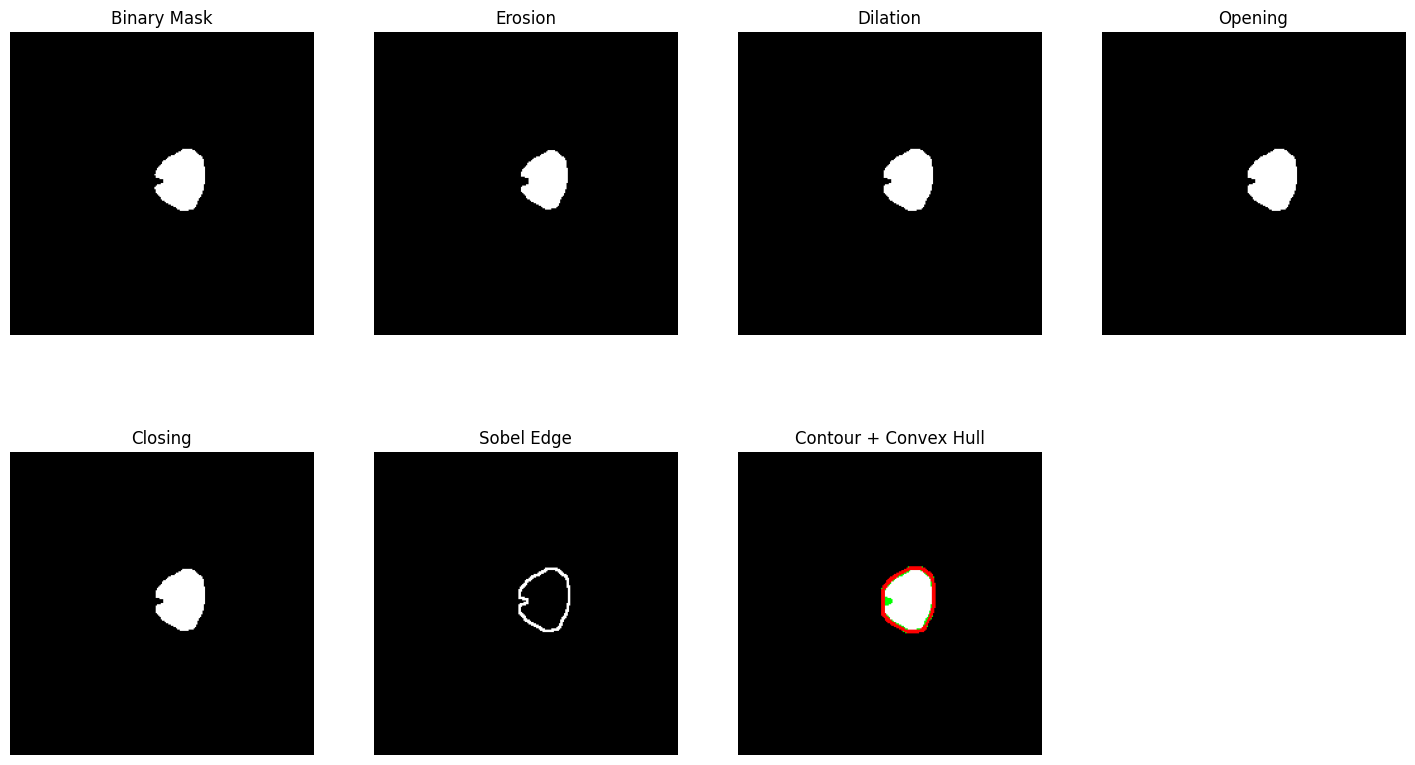

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00249-000_result.png

Processing: BraTS-PED-00237-000
Best Slice: 41

Chain Code:
[5, 4, 4, 4, 4, 5, 4, 5, 4, 5, 5, 5, 4, 6, 5, 6, 6, 6, 5, 5, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6]

First Difference:
[7, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 7, 2, 7, 1, 0, 0, 7, 0, 7, 1, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 7, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 0, 1, 0, 0, 7, 0, 1, 7, 1, 0, 0, 7, 1, 0, 7, 1, 0, 0, 0, 7, 0, 1, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 1, 7]


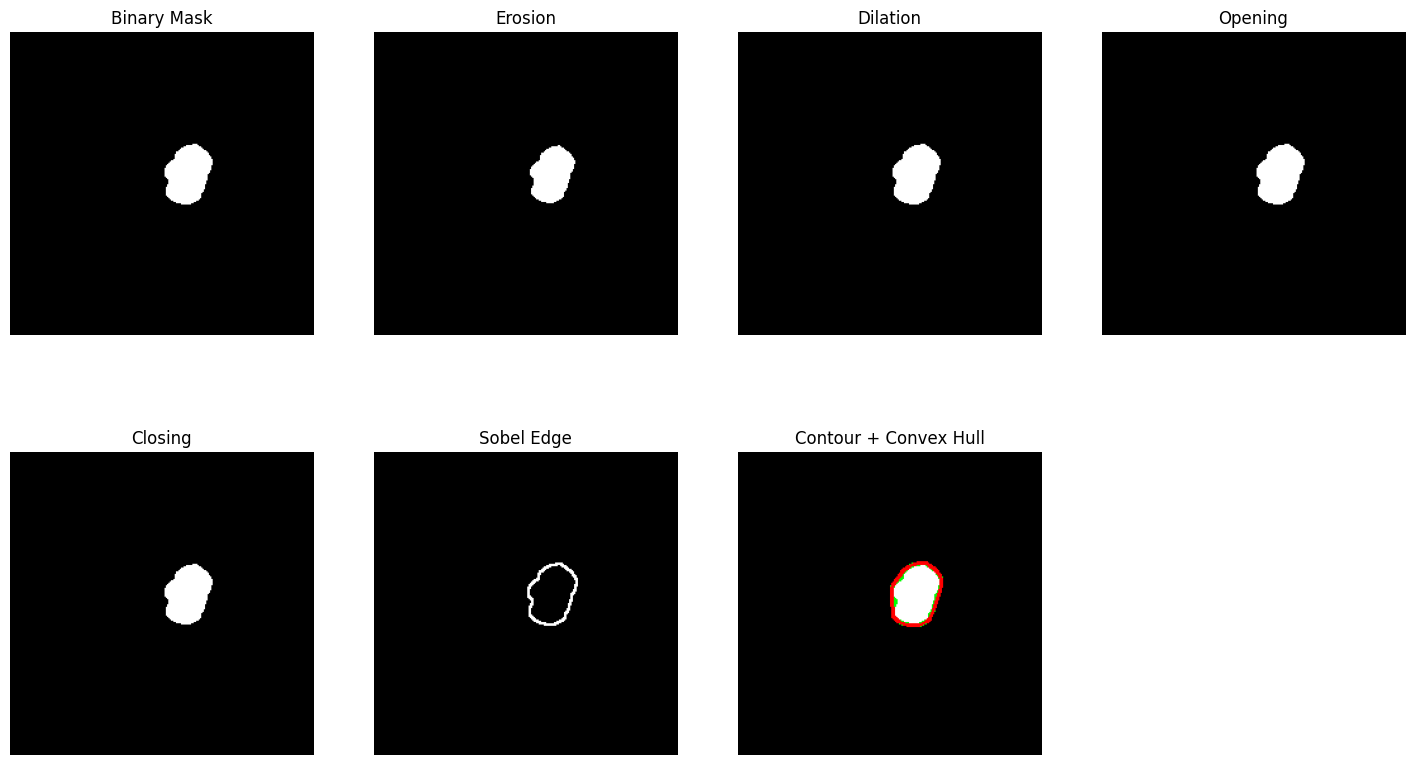

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00237-000_result.png

Processing: BraTS-PED-00235-000
Best Slice: 42

Chain Code:
[5, 4, 5, 5, 4, 5, 5, 5, 5, 5, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 7, 0, 7, 6, 5, 4, 5, 5, 6, 6, 6, 6, 6, 6, 7, 6, 6, 7, 6, 7, 6, 7, 6, 7, 7, 7, 7]

First Difference:
[7, 1, 0, 7, 1, 0, 0, 0, 0, 1, 7, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 1, 1, 7, 7, 7, 7, 1, 0, 1, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 7, 1, 0, 0, 0, 7]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 1, 7, 1, 7, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 1, 0, 7, 1, 0]


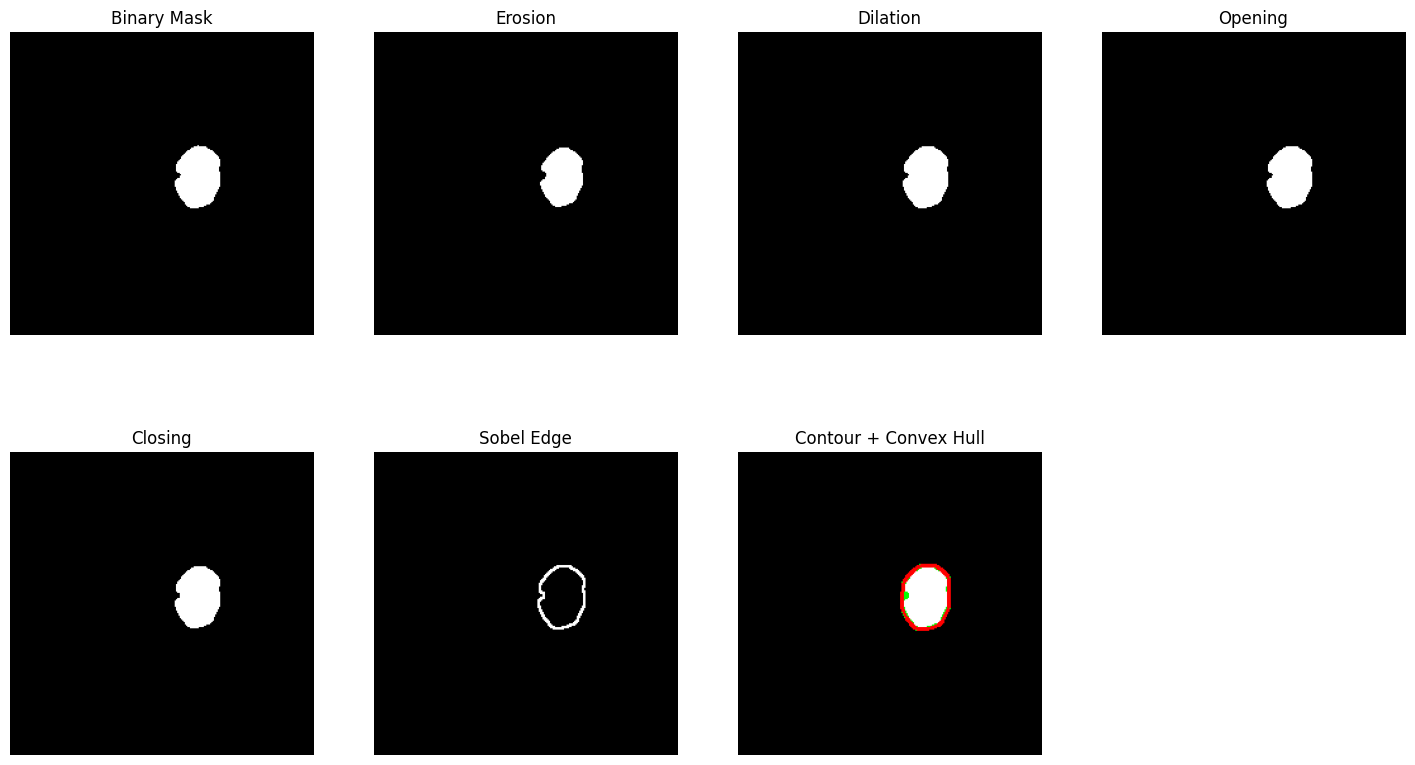

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00235-000_result.png

Processing: BraTS-PED-00230-000
Best Slice: 37

Chain Code:
[5, 4, 5, 4, 5, 5, 4, 5, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 7, 7, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]

First Difference:
[7, 1, 7, 1, 0, 7, 1, 7, 0, 1, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 7, 0, 6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 1, 7, 1, 0, 7, 1, 7, 0, 1, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 7, 0]


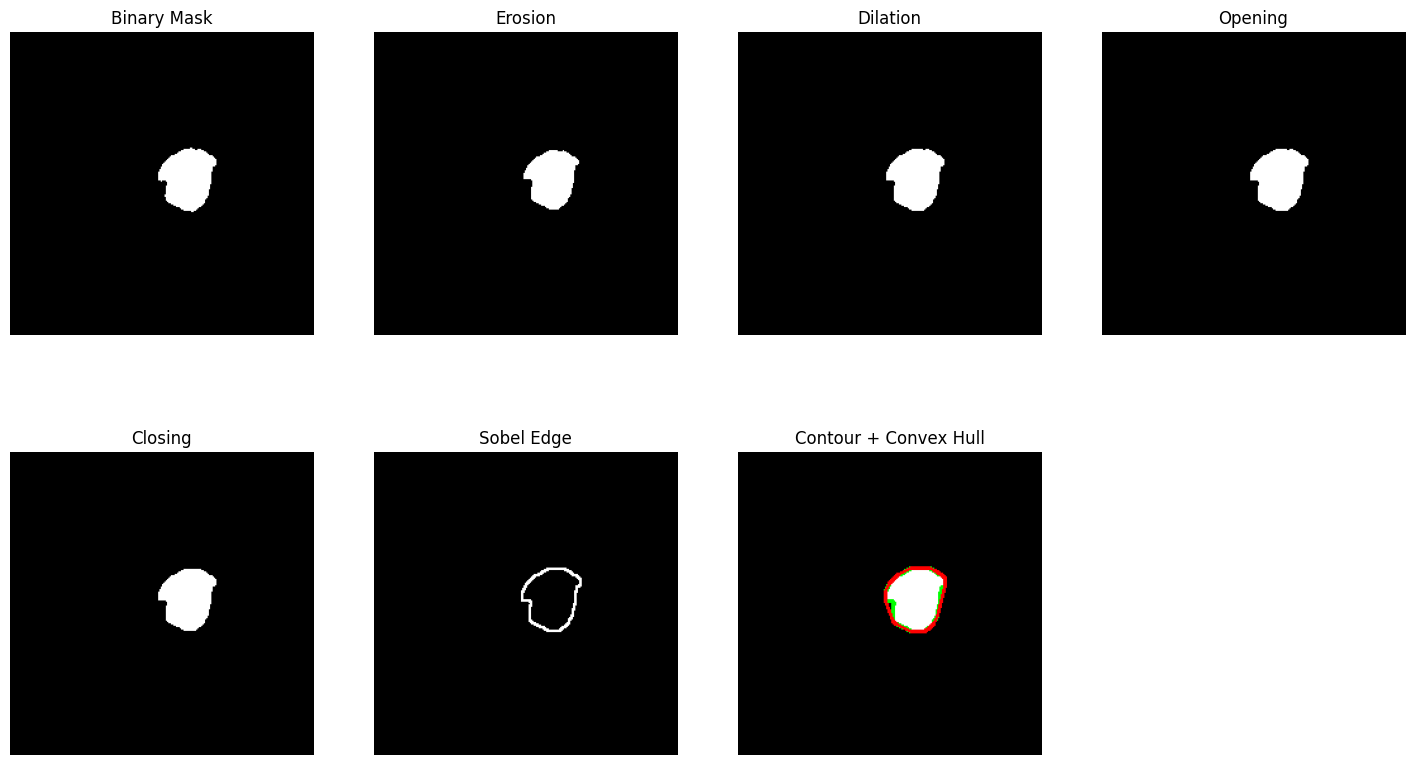

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00230-000_result.png

Processing: BraTS-PED-00233-000
Best Slice: 34

Chain Code:
[5, 4, 4, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 5, 5, 4, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 6, 7, 7, 7, 7, 7, 7, 7, 7]

First Difference:
[7, 0, 1, 0, 7, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 1, 0, 0, 0, 0, 0, 1, 0, 0, 6, 0, 7, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 1, 0, 0, 7, 0, 1, 7, 7, 1, 1, 7, 0, 1, 7, 1, 0, 7, 1, 0, 0]


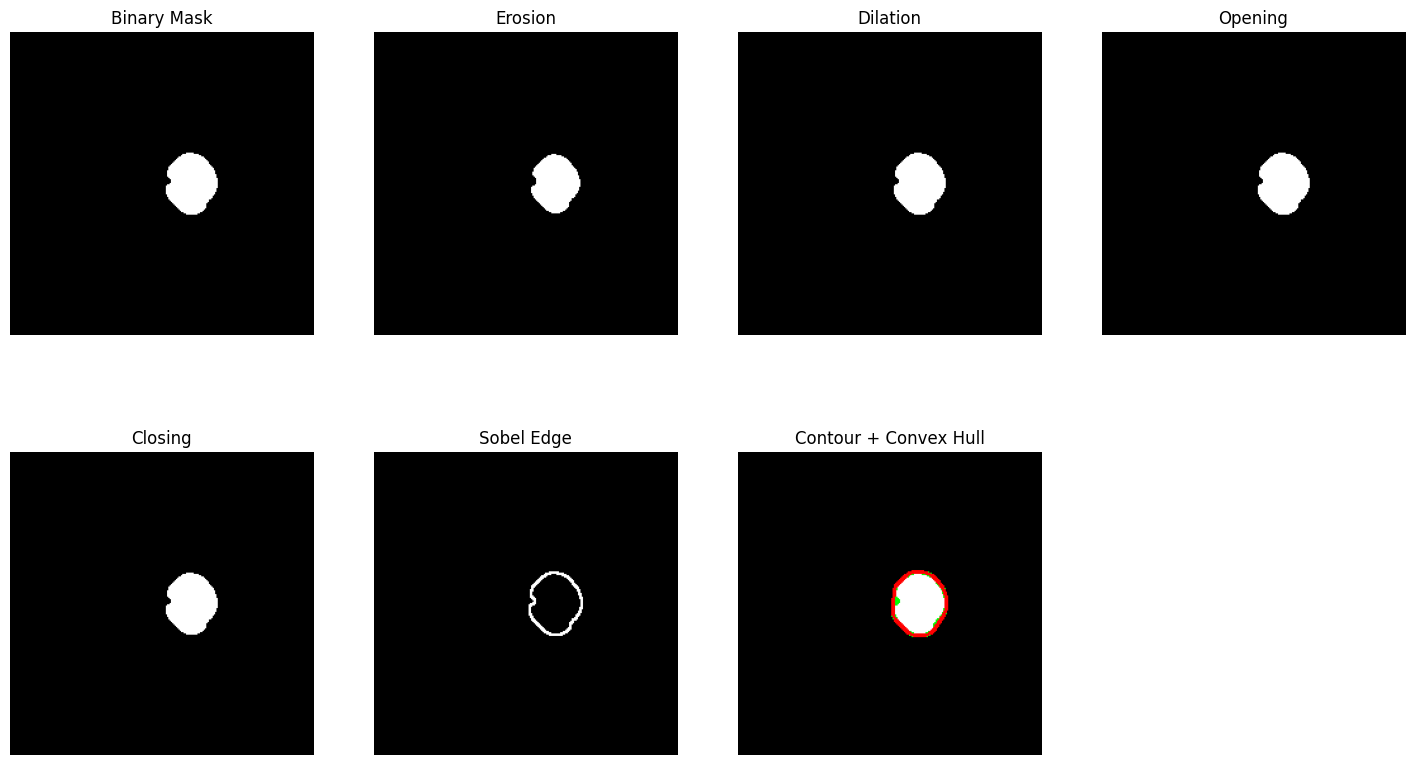

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00233-000_result.png

Processing: BraTS-PED-00226-000
Best Slice: 44

Chain Code:
[5, 4, 5, 4, 5, 4, 5, 5, 5, 6, 5, 5, 4, 5, 4, 5, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 6, 6, 7, 6, 7, 7, 7, 7, 0, 7, 7, 7, 0, 7, 7, 7, 7, 0, 0, 7, 0, 0, 0, 0]

First Difference:
[7, 1, 7, 1, 7, 1, 0, 0, 1, 7, 0, 7, 1, 7, 1, 1, 0, 7, 1, 0, 0, 0, 0, 1, 7, 0, 0, 1, 7, 1, 0, 0, 0, 1, 7, 0, 0, 1, 7, 0, 0, 0, 1, 0, 7, 1, 0, 0, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 1, 7, 1, 7, 1, 7, 1, 0, 7, 1, 0, 0, 0, 7, 1, 7, 1, 7, 1, 0, 0, 1, 7, 0, 7, 1, 7, 1, 1, 0, 7, 1, 0, 0, 0, 0]


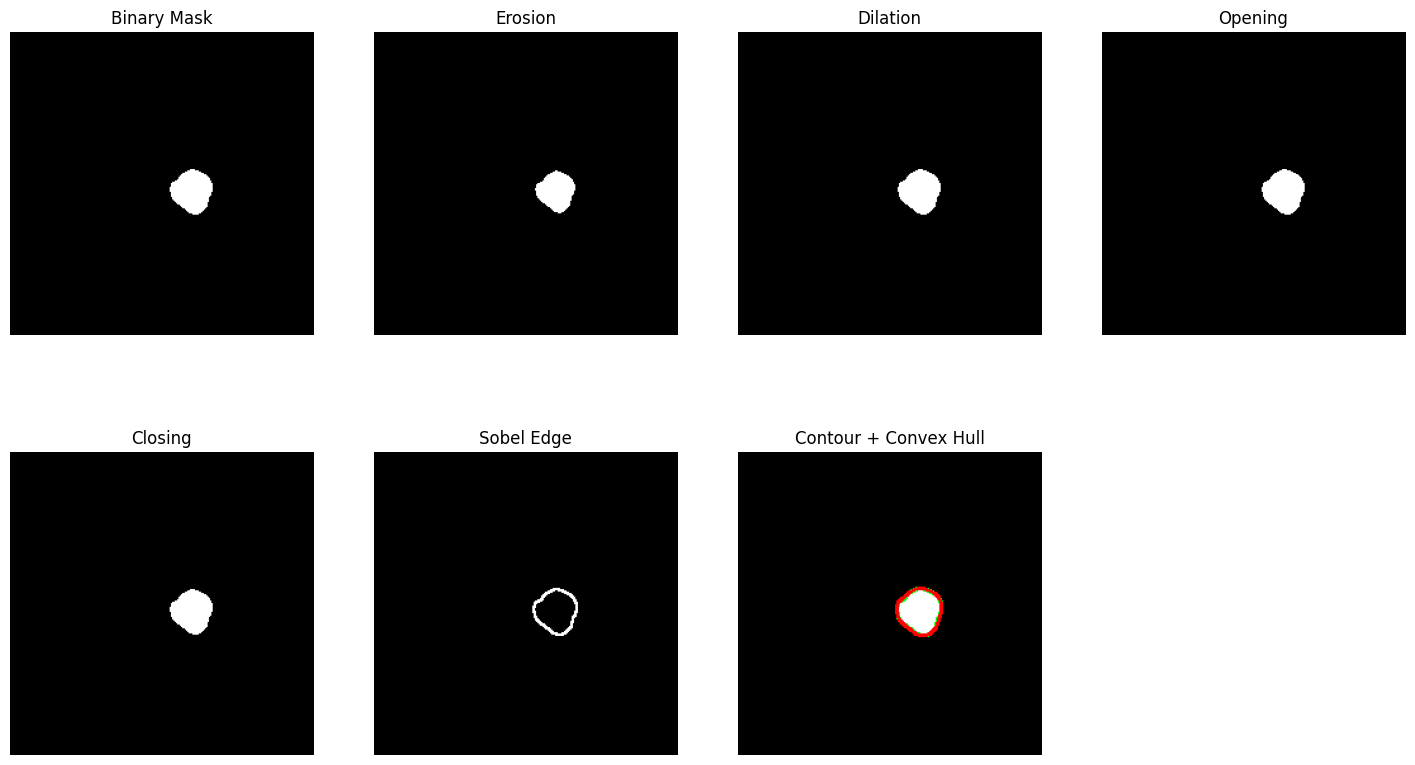

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00226-000_result.png

Processing: BraTS-PED-00234-000
Best Slice: 39

Chain Code:
[5, 4, 5, 5, 4, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 0, 7, 7]

First Difference:
[7, 1, 0, 7, 1, 0, 0, 0, 7, 1, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 1, 6, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 7, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 7, 0, 1, 7, 1, 0, 7, 1, 0, 7, 1, 7, 1, 0, 1, 7, 1, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0]


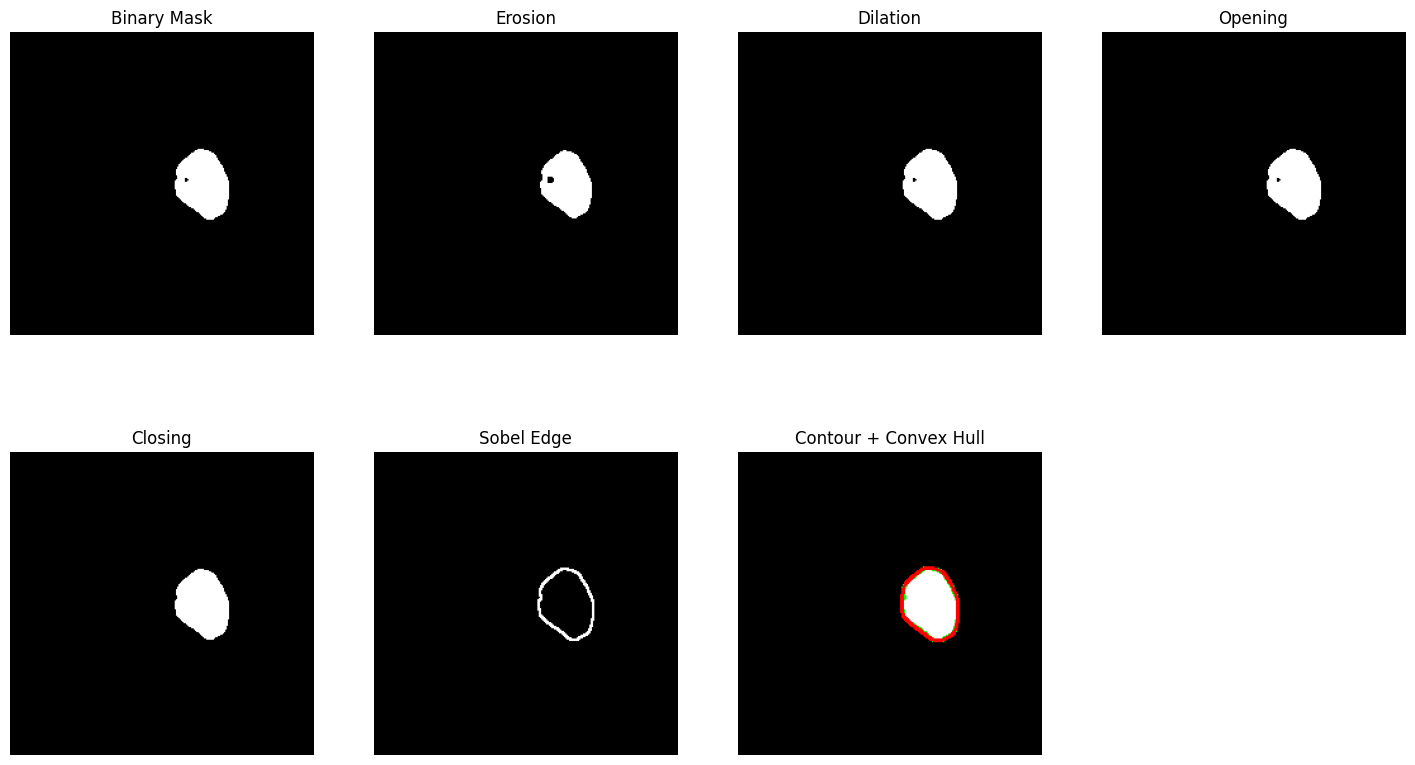

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00234-000_result.png

Processing: BraTS-PED-00227-000
Best Slice: 46

Chain Code:
[5, 5, 4, 5, 4, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 6, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 6, 7, 5, 6, 6, 6, 6, 7, 0, 0, 0, 7, 0, 0, 7, 0, 0]

First Difference:
[0, 7, 1, 7, 0, 1, 7, 1, 7, 1, 7, 1, 7, 1, 1, 7, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 1, 0, 0, 7, 1, 6, 1, 0, 0, 0, 1, 1, 0, 0, 7, 1, 0, 7, 1, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 0, 7, 2, 7, 1, 0, 0, 0, 0, 7, 1, 7, 0, 1, 7, 1, 7, 1, 7, 1, 7, 1, 1, 7, 0, 0, 0]


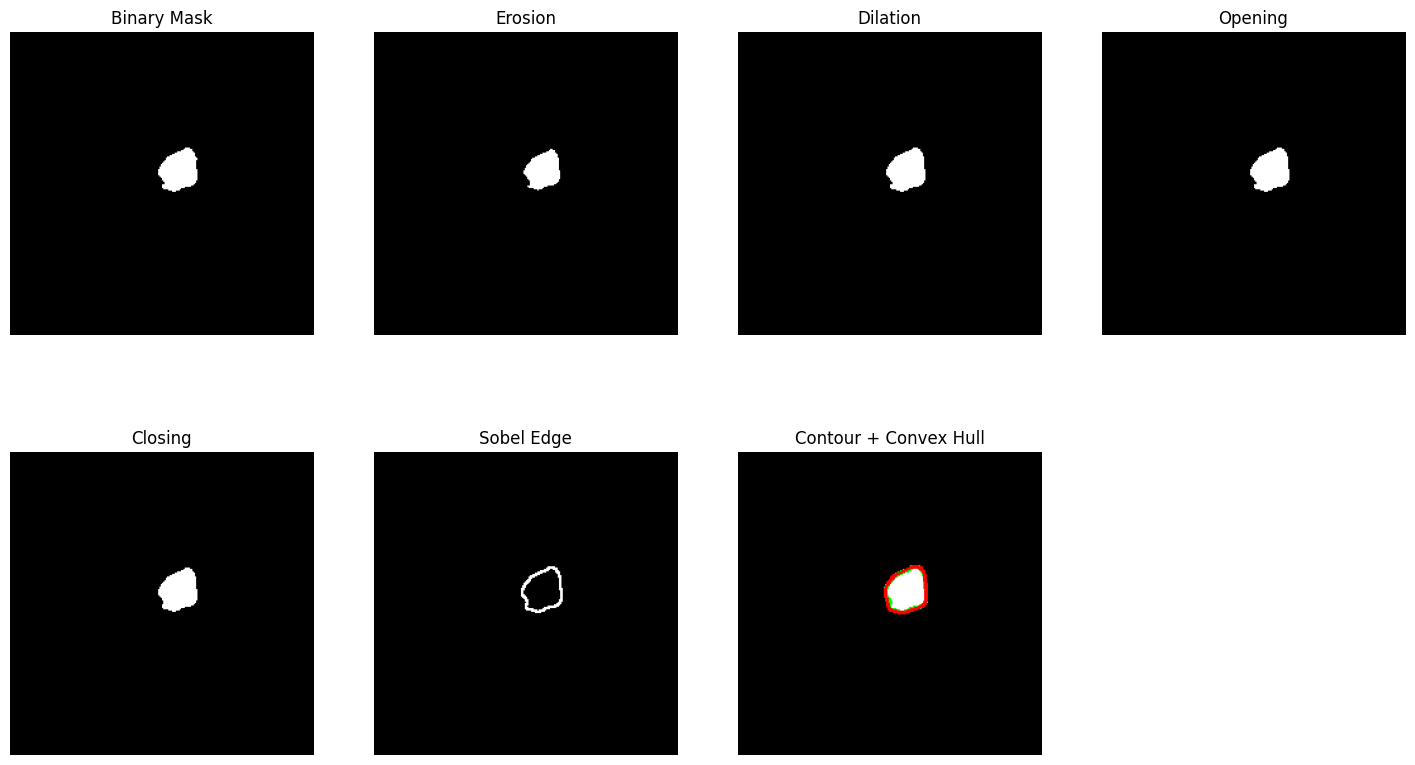

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00227-000_result.png

Processing: BraTS-PED-00231-000
Best Slice: 39

Chain Code:
[5, 5, 4, 5, 6, 6, 6, 5, 5, 5, 4, 6, 5, 5, 5, 6, 6, 6, 6, 7, 6, 7, 7, 7, 7, 7, 7, 0, 7, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 2, 1, 1, 2]

First Difference:
[0, 7, 1, 1, 0, 0, 7, 0, 0, 7, 2, 7, 0, 0, 1, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 0, 0, 1, 1, 0, 7, 0, 1, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 0, 0, 0, 1, 1, 0, 7, 0, 1, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 1, 0, 0, 0, 7, 1, 0, 0, 0, 0, 7, 1, 1]


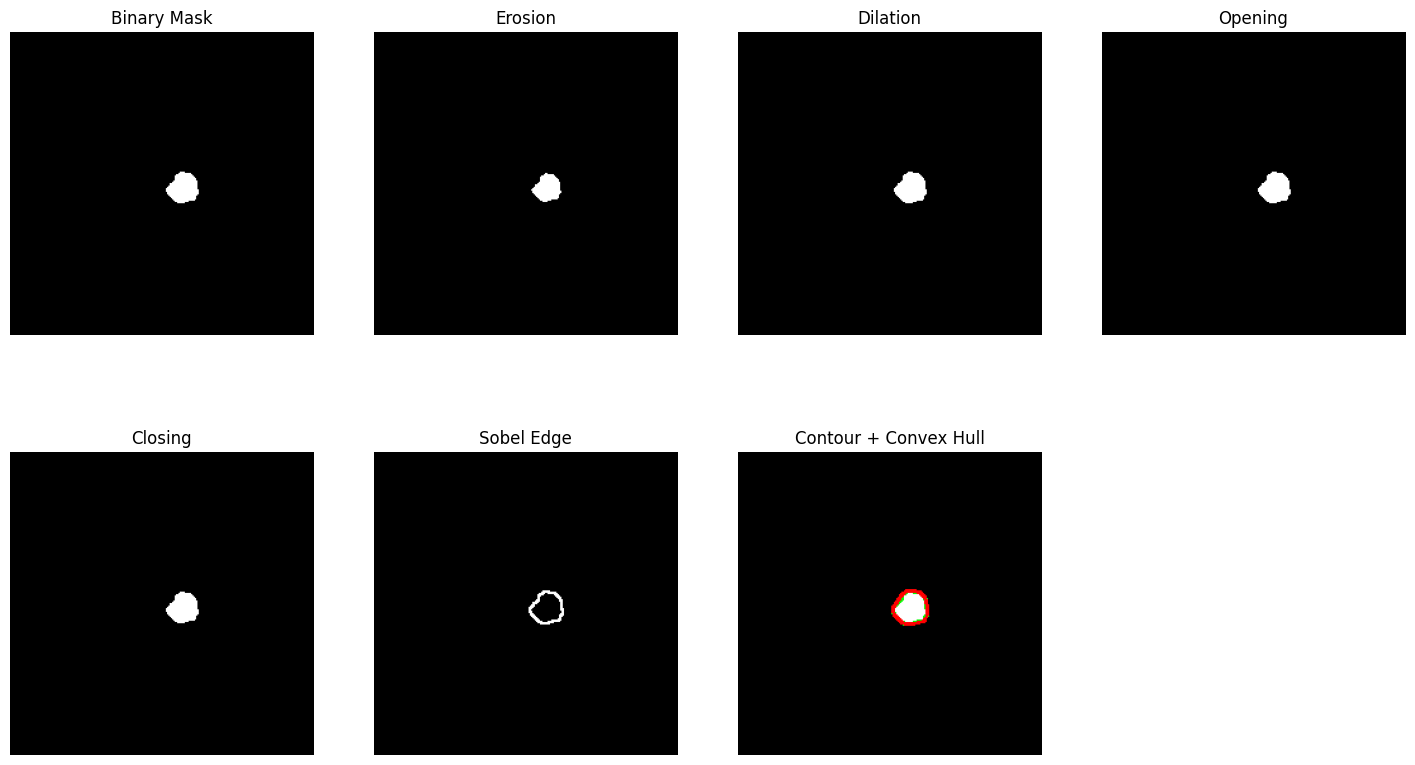

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00231-000_result.png

Processing: BraTS-PED-00228-000
Best Slice: 64

Chain Code:
[5, 4, 4, 5, 4, 4, 5, 4, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 7, 6, 7, 6, 7, 5, 5, 5, 6, 6, 6, 6, 7, 6, 6, 0, 7, 0, 7, 7, 7, 0, 7, 0, 0]

First Difference:
[7, 0, 1, 7, 0, 1, 7, 1, 0, 0, 0, 1, 7, 0, 1, 0, 7, 1, 0, 0, 0, 0, 1, 7, 1, 7, 1, 7, 1, 6, 0, 0, 1, 0, 0, 0, 1, 7, 0, 2, 7, 1, 7, 0, 0, 1, 7, 1, 0, 0]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 7, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 1, 7, 0, 0, 0, 0, 1, 7, 1, 0, 0]


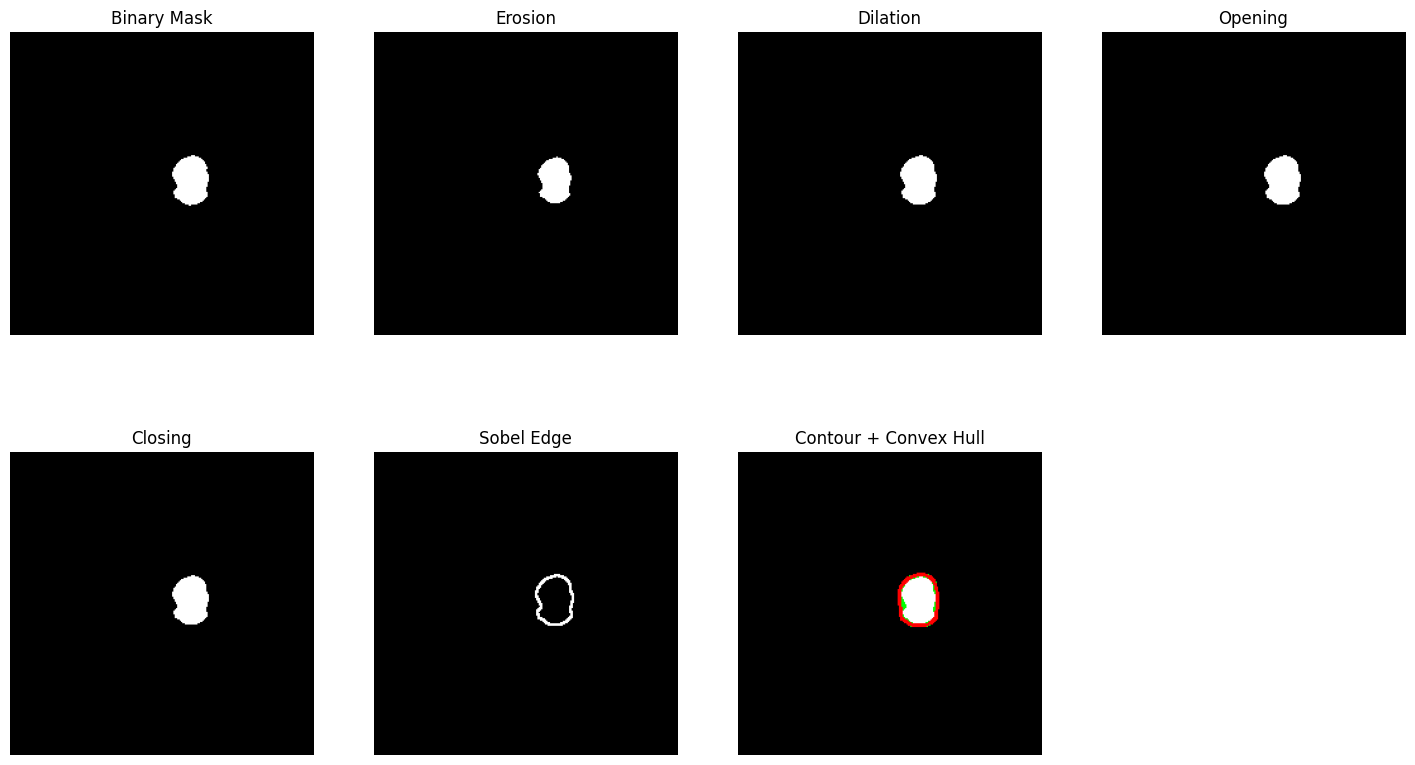

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00228-000_result.png

Processing: BraTS-PED-00232-000
Best Slice: 37

Chain Code:
[5, 4, 5, 4, 4, 4, 5, 4, 4, 5, 4, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 7, 6, 0, 7, 7, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6]

First Difference:
[7, 1, 7, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 1, 7, 2, 7, 0, 7, 0, 7, 0, 1, 0, 0, 0, 0, 0, 1]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 0, 7, 1, 7, 0, 0, 0, 0, 0, 1, 7, 1, 1, 0, 0, 0, 0, 7, 1, 7, 0, 0, 1, 7, 0, 1, 7, 1, 0, 0, 7, 1]


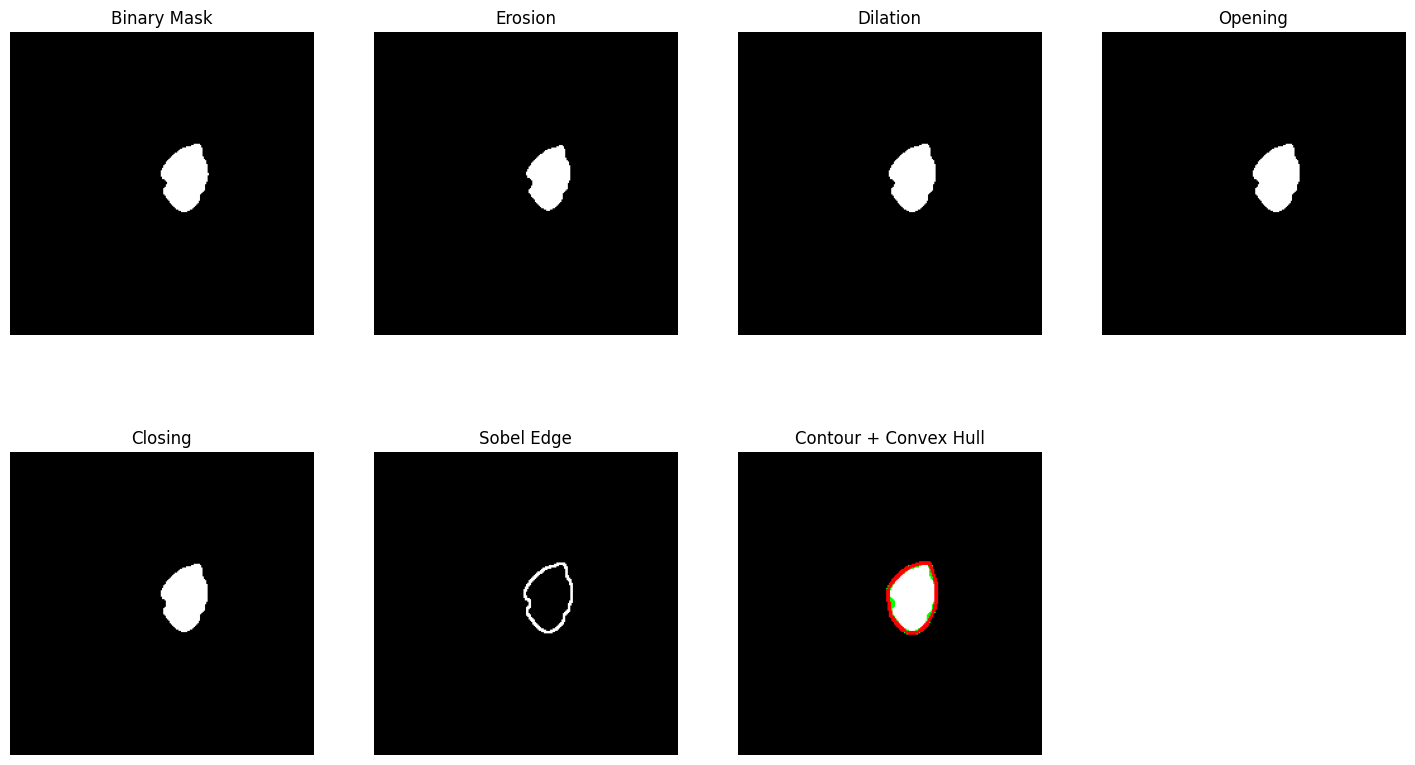

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00232-000_result.png

Processing: BraTS-PED-00229-000
Best Slice: 41

Chain Code:
[5, 4, 5, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 7, 7, 7, 0, 7, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

First Difference:
[7, 1, 7, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 7, 1, 0, 0, 7, 1, 0, 0, 0, 0, 0, 0, 1, 7, 1, 0, 0, 0, 1, 7, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7]

Shape Number:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 7, 1, 0, 0, 0, 1, 7, 0, 0, 1, 7, 0, 1, 1, 7, 0, 0, 1, 0, 0, 0, 0, 0]


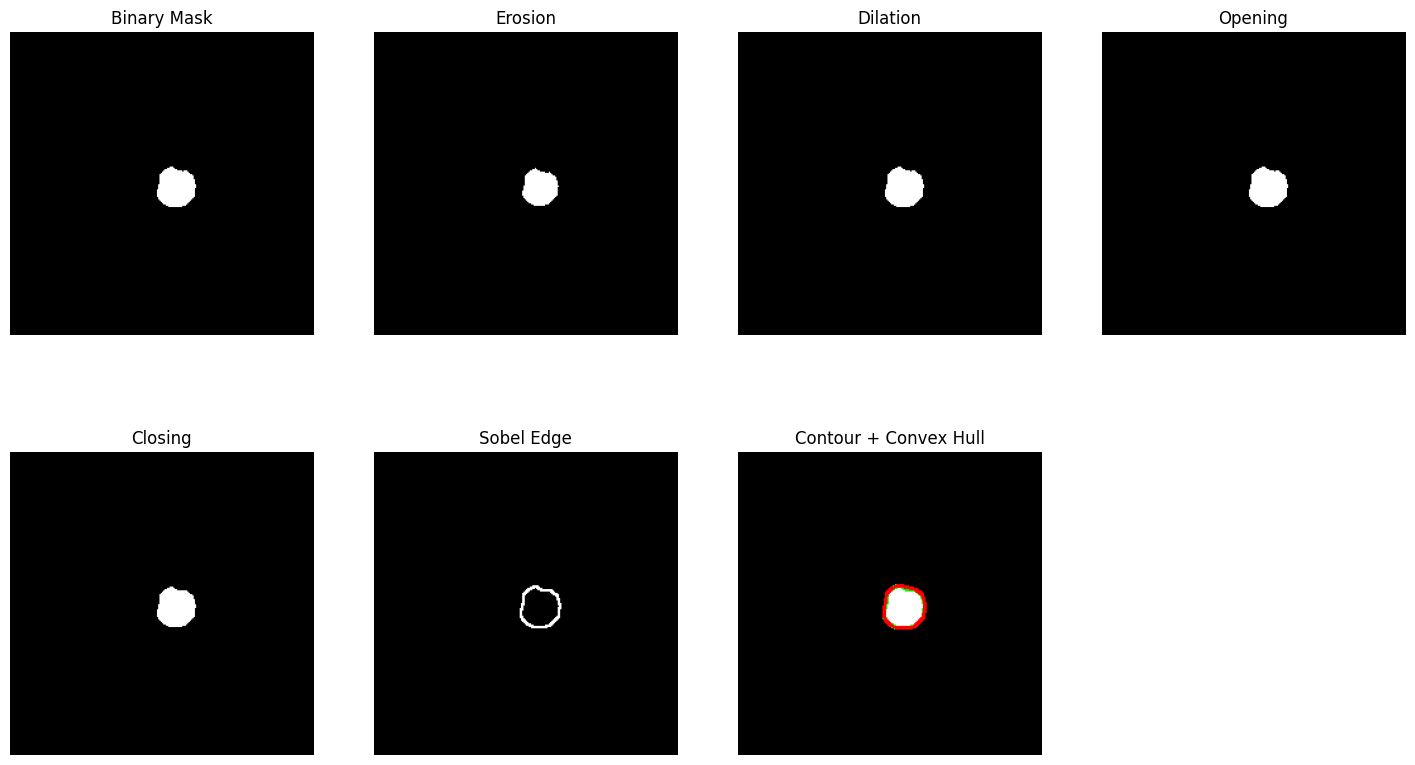

Saved: /content/drive/MyDrive/BrainTumorResults/BraTS-PED-00229-000_result.png


In [22]:
import os
import cv2
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# dataset
dataset = "/content/drive/MyDrive/group 10/group 10"

# patient folder
patients = os.listdir(dataset)

# results folder
results_folder = "/content/drive/MyDrive/BrainTumorResults"
os.makedirs(results_folder, exist_ok=True)

# Freeman Chain Code Directions
directions = {
    (1, 0): 0,
    (1, -1): 1,
    (0, -1): 2,
    (-1, -1): 3,
    (-1, 0): 4,
    (-1, 1): 5,
    (0, 1): 6,
    (1, 1): 7
}

# loop through patients
for patient in patients:

    patient_path = os.path.join(dataset, patient)

    if not os.path.isdir(patient_path):
        continue

    print("\nProcessing:", patient)

    # segmentation file
    seg_file = [
        f for f in os.listdir(patient_path)
        if "seg" in f
    ][0]

    seg_path = os.path.join(
        patient_path,
        seg_file
    )

    img = nib.load(seg_path)
    data = img.get_fdata()

    # find slice with largest tumor
    max_pixels = 0
    best_slice = 0

    for i in range(data.shape[2]):

        current_slice = data[:, :, i]

        tumor_pixels = np.sum(
            current_slice > 0
        )

        if tumor_pixels > max_pixels:

            max_pixels = tumor_pixels
            best_slice = i

    print("Best Slice:", best_slice)

    # extract best slice
    mask = data[:, :, best_slice]

    # binary mask
    binary = np.where(
        mask > 0,
        255,
        0
    ).astype(np.uint8)

    # ======================
    # Morphological Operations
    # ======================

    kernel = np.ones((3,3), np.uint8)

    erosion = cv2.erode(
        binary,
        kernel,
        iterations=1
    )

    dilation = cv2.dilate(
        erosion,
        kernel,
        iterations=1
    )

    opening = cv2.morphologyEx(
        dilation,
        cv2.MORPH_OPEN,
        kernel
    )

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    cleaned_mask = closing

    # ======================
    # Sobel Edge Detection
    # ======================

    sobel_x = cv2.Sobel(
        cleaned_mask,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        cleaned_mask,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel = cv2.magnitude(
        sobel_x,
        sobel_y
    )

    sobel = cv2.convertScaleAbs(
        sobel
    )

    # ======================
    # Contours
    # ======================

    contours, _ = cv2.findContours(
        sobel,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        print("No contour found")
        continue

    contour = max(
        contours,
        key=cv2.contourArea
    )

    # ======================
    # Chain Code
    # ======================

    chain_code = []

    points = contour.squeeze()

    for i in range(len(points)-1):

        x1, y1 = points[i]
        x2, y2 = points[i+1]

        dx = np.sign(x2 - x1)
        dy = np.sign(y2 - y1)

        direction = directions.get(
            (dx, dy)
        )

        if direction is not None:
            chain_code.append(direction)

    print("\nChain Code:")
    print(chain_code[:50])

    # ======================
    # First Difference
    # ======================

    first_difference = []

    for i in range(len(chain_code)-1):

        diff = (
            chain_code[i+1]
            -
            chain_code[i]
        ) % 8

        first_difference.append(diff)

    print("\nFirst Difference:")
    print(first_difference[:50])

    # ======================
    # Shape Number
    # ======================

    shape_number = min(
        [
            first_difference[i:]
            +
            first_difference[:i]

            for i in range(
                len(first_difference)
            )
        ]
    )

    print("\nShape Number:")
    print(shape_number[:50])

    # ======================
    # Convex Hull
    # ======================

    hull = cv2.convexHull(
        contour
    )

    overlay = cv2.cvtColor(
        cleaned_mask,
        cv2.COLOR_GRAY2BGR
    )

    cv2.drawContours(
        overlay,
        [contour],
        -1,
        (0,255,0),
        2
    )

    cv2.drawContours(
        overlay,
        [hull],
        -1,
        (255,0,0),
        2
    )

    # ======================
    # Display Results
    # ======================

    plt.figure(figsize=(18,10))

    plt.subplot(2,4,1)
    plt.imshow(binary, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(erosion, cmap="gray")
    plt.title("Erosion")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(dilation, cmap="gray")
    plt.title("Dilation")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(opening, cmap="gray")
    plt.title("Opening")
    plt.axis("off")

    plt.subplot(2,4,5)
    plt.imshow(closing, cmap="gray")
    plt.title("Closing")
    plt.axis("off")

    plt.subplot(2,4,6)
    plt.imshow(sobel, cmap="gray")
    plt.title("Sobel Edge")
    plt.axis("off")

    plt.subplot(2,4,7)
    plt.imshow(overlay)
    plt.title("Contour + Convex Hull")
    plt.axis("off")

    save_path = os.path.join(
        results_folder,
        patient + "_result.png"
    )

    plt.savefig(
        save_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", save_path)

### **From Assignment # 03**

In [23]:
import os
import cv2
import nibabel as nib
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix
from skimage.feature import graycoprops

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# =====================================
# Dataset
# =====================================

dataset = "/content/drive/MyDrive/group 10/group 10"

feature_data = []

patients = os.listdir(dataset)

# =====================================
# Feature Extraction
# =====================================

for patient in patients:

    patient_path = os.path.join(
        dataset,
        patient
    )

    if not os.path.isdir(patient_path):
        continue

    print("\nProcessing:", patient)

    # segmentation file
    seg_file = [
        f for f in os.listdir(patient_path)
        if "seg" in f
    ][0]

    seg_path = os.path.join(
        patient_path,
        seg_file
    )

    seg_img = nib.load(seg_path)

    seg_data = seg_img.get_fdata()

    # best slice
    max_pixels = 0
    best_slice = 0

    for i in range(seg_data.shape[2]):

        current_slice = seg_data[:, :, i]

        tumor_pixels = np.sum(
            current_slice > 0
        )

        if tumor_pixels > max_pixels:

            max_pixels = tumor_pixels

            best_slice = i

    print("Best Slice:", best_slice)

    # mask
    mask = seg_data[:, :, best_slice]

    binary_mask = np.where(
        mask > 0,
        255,
        0
    ).astype(np.uint8)

    # =====================================
    # MRI Image
    # =====================================

    mri_file = [
        f for f in os.listdir(patient_path)
        if "t1c" in f
    ][0]

    mri_path = os.path.join(
        patient_path,
        mri_file
    )

    mri_img = nib.load(
        mri_path
    )

    mri_data = mri_img.get_fdata()

    slice_img = mri_data[:, :, best_slice]

    # normalize
    slice_img = cv2.normalize(
        slice_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # apply mask
    masked_region = cv2.bitwise_and(
        slice_img,
        slice_img,
        mask=binary_mask
    )

    # =====================================
    # GLCM Features
    # =====================================

    glcm = graycomatrix(
        masked_region,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    energy = graycoprops(
        glcm,
        "energy"
    )[0,0]

    contrast = graycoprops(
        glcm,
        "contrast"
    )[0,0]

    glcm_prob = glcm / np.sum(glcm)

    entropy = -np.sum(
        glcm_prob *
        np.log2(glcm_prob + 1e-10)
    )

    # =====================================
    # Geometric Features
    # =====================================

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(
        contour
    )

    perimeter = cv2.arcLength(
        contour,
        True
    )

    circularity = (
        4 * np.pi * area
    ) / (
        perimeter * perimeter + 1e-10
    )

    M = cv2.moments(
        contour
    )

    cx = int(
        M["m10"] /
        (M["m00"] + 1e-10)
    )

    cy = int(
        M["m01"] /
        (M["m00"] + 1e-10)
    )

    feature_data.append([
        patient + ".png",
        energy,
        entropy,
        contrast,
        area,
        perimeter,
        circularity,
        cx,
        cy
    ])

# =====================================
# DataFrame
# =====================================

columns = [
    "Image",
    "Energy",
    "Entropy",
    "Contrast",
    "Area",
    "Perimeter",
    "Circularity",
    "Centroid_X",
    "Centroid_Y"
]

df = pd.DataFrame(
    feature_data,
    columns=columns
)

# =====================================
# Labels using Median Area
# =====================================

median_area = df["Area"].median()

df["Label"] = np.where(
    df["Area"] > median_area,
    1,
    0
)

print("\nMedian Area:", median_area)

print("\nLabel Distribution:")
print(
    df["Label"].value_counts()
)

# =====================================
# Save CSV
# =====================================

csv_path = "/content/drive/MyDrive/Feature_Vector.csv"

df.to_csv(
    csv_path,
    index=False
)

print("\nFeature CSV Saved Successfully")

# =====================================
# Random Forest Classification
# =====================================

X = df.drop(
    columns=[
        "Image",
        "Label"
    ]
)

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred = rf.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nRandom Forest Accuracy:")
print(accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Processing: BraTS-PED-00246-000
Best Slice: 34

Processing: BraTS-PED-00251-000
Best Slice: 33

Processing: BraTS-PED-00245-000
Best Slice: 42

Processing: BraTS-PED-00241-000
Best Slice: 37

Processing: BraTS-PED-00244-000
Best Slice: 36

Processing: BraTS-PED-00243-000
Best Slice: 34

Processing: BraTS-PED-00242-000
Best Slice: 32

Processing: BraTS-PED-00248-000
Best Slice: 39

Processing: BraTS-PED-00239-000
Best Slice: 25

Processing: BraTS-PED-00247-000
Best Slice: 63

Processing: BraTS-PED-00240-000
Best Slice: 52

Processing: BraTS-PED-00238-000
Best Slice: 43

Processing: BraTS-PED-00236-000
Best Slice: 38

Processing: BraTS-PED-00249-000
Best Slice: 43

Processing: BraTS-PED-00237-000
Best Slice: 41

Processing: BraTS-PED-00235-000
Best Slice: 42

Processing: BraTS-PED-00230-000
Best Slice: 37

Processing: BraTS-PED-00233-000
Best Slice: 34

Processing: BraTS-PED-00226-000
Best Slice: 44

Processing: BraTS-PED-00234-000
Best Slice: 39

Processing: BraTS-PED-00227-000
Best Sl

### **For Making Labels**

In [6]:
import os
import shutil
import pandas as pd

csv_file = "/content/drive/MyDrive/Feature_Vector.csv"

images_folder = "/content/drive/MyDrive/Processed_MRI"

dataset_folder = "/content/drive/MyDrive/BrainTumorDataset"

high_folder = os.path.join(dataset_folder, "High_Risk")
low_folder = os.path.join(dataset_folder, "Low_Risk")

os.makedirs(high_folder, exist_ok=True)
os.makedirs(low_folder, exist_ok=True)

df = pd.read_csv(csv_file)
median_area = df["Area"].median()

for _, row in df.iterrows():
    image_name = row["Image"]
    area = row["Area"]

    source = os.path.join(images_folder,image_name)

    if area > median_area:

        destination = os.path.join(high_folder,image_name)

    else:

        destination = os.path.join(low_folder,image_name)

    shutil.copy(source,destination)

print("Dataset Created")

Dataset Created


### **CNN**

In [24]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# =====================================
# Dataset Path
# =====================================

dataset_path = "/content/drive/MyDrive/BrainTumorDataset"

img_height = 128
img_width = 128

# =====================================
# Load Dataset
# =====================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=8,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=8,
    color_mode="grayscale"
)

# =====================================
# Data Augmentation
# =====================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

# =====================================
# CNN Model
# =====================================

model = Sequential()

# Input Layer
model.add(
    tf.keras.layers.Input(
        shape=(128,128,1)
    )
)

# Data Augmentation Layer
model.add(
    data_augmentation
)

# -------------------------------------
# First Convolution Block
# -------------------------------------

model.add(
    Conv2D(
        32,
        (5,5),
        activation="relu"
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling2D((2,2))
)

# -------------------------------------
# Second Convolution Block
# -------------------------------------

model.add(
    Conv2D(
        64,
        (5,5),
        activation="relu"
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling2D((2,2))
)

# -------------------------------------
# Third Convolution Block
# -------------------------------------

model.add(
    Conv2D(
        128,
        (5,5),
        activation="relu"
    )
)

model.add(
    BatchNormalization()
)

model.add(
    MaxPooling2D((2,2))
)

# -------------------------------------
# Fully Connected Layers
# -------------------------------------

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# =====================================
# Compile Model
# =====================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =====================================
# Summary
# =====================================

model.summary()

# =====================================
# Early Stopping
# =====================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# =====================================
# Training
# =====================================

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[early_stop]
)

# =====================================
# Evaluation
# =====================================

loss, accuracy = model.evaluate(
    test_dataset
)

print("\nTest Accuracy:", accuracy)

Found 25 files belonging to 2 classes.
Using 20 files for training.
Found 25 files belonging to 2 classes.
Using 5 files for validation.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 58, 58, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 58, 58, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617,473 (9.98 MB)

 Trainable params: 2,617,025 (9.98 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 494ms/step - accuracy: 0.5500 - loss: 4.8677 - val_accuracy: 0.8000 - val_loss: 1.3209
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4500 - loss: 4.1920 - val_accuracy: 0.6000 - val_loss: 21.3821
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 4.1562 - val_accuracy: 0.6000 - val_loss: 27.4945
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 5.1069 - val_accuracy: 0.6000 - val_loss: 34.1001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8000 - loss: 1.3209

Test Accuracy: 0.800000011920929


In [25]:
import numpy as np

# store actual labels
y_true = []

# store predicted labels
y_pred = []

# loop through test data
for images, labels in test_dataset:
    predictions = model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[2 1]
 [0 2]]


**CLASSIFICATION REPORT**

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Low_Risk",
            "High_Risk"
        ]
    )
)

              precision    recall  f1-score   support

    Low_Risk       1.00      0.67      0.80         3
   High_Risk       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



**CONFUSION MATRIX**

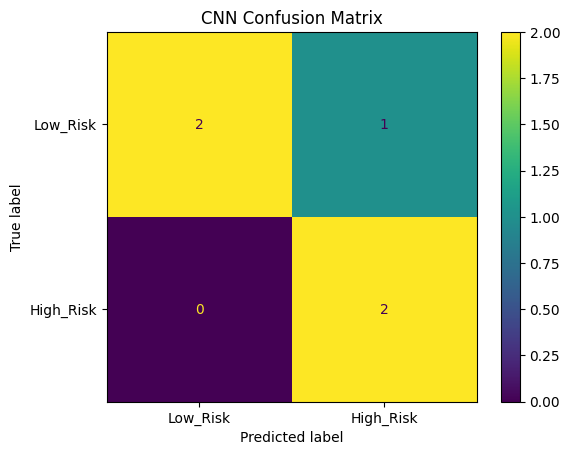

In [28]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Low_Risk",
        "High_Risk"
    ]
)

disp.plot()

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

**ACCURACY PLOT**

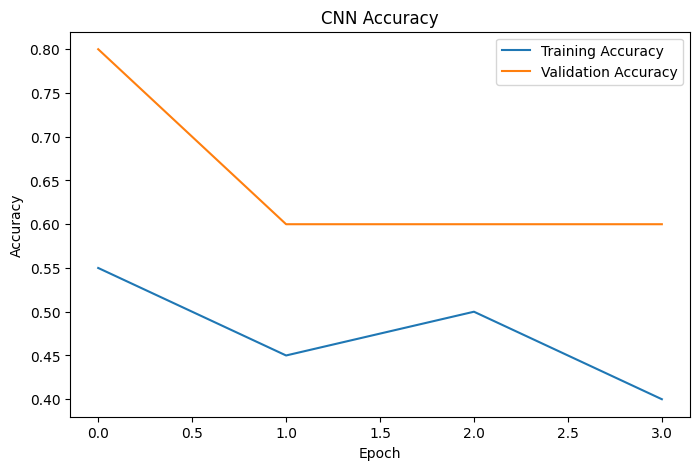

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "CNN Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

**LOSS PLOT**

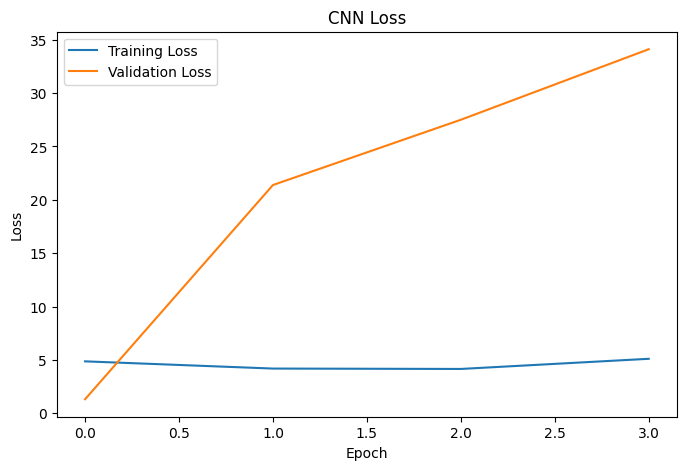

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "CNN Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

### **Transformer**

**Load MRI Volumes**

In [2]:
import os
import nibabel as nib
import numpy as np

from scipy.ndimage import zoom

# dataset

dataset = "/content/drive/MyDrive/group 10/group 10"

patients = os.listdir(dataset)

# storage

X = []

tumor_sizes = []

patient_names = []

# ==========================
# First Pass
# ==========================

for patient in patients:

    patient_path = os.path.join(
        dataset,
        patient
    )

    if not os.path.isdir(patient_path):
        continue

    print("Processing:", patient)

    # t1c MRI

    mri_file = [
        f for f in os.listdir(patient_path)
        if "t1c" in f
    ][0]

    # segmentation file

    seg_file = [
        f for f in os.listdir(patient_path)
        if "seg" in f
    ][0]

    # load MRI

    mri_path = os.path.join(
        patient_path,
        mri_file
    )

    mri = nib.load(
        mri_path
    )

    volume = mri.get_fdata()

    # load segmentation

    seg_path = os.path.join(
        patient_path,
        seg_file
    )

    seg = nib.load(
        seg_path
    )

    mask = seg.get_fdata()

    # tumor size

    tumor_pixels = np.sum(
        mask > 0
    )

    tumor_sizes.append(
        tumor_pixels
    )

    patient_names.append(
        patient
    )

    # apply mask

    tumor_volume = volume * (
        mask > 0
    )

    # normalize

    tumor_volume = (

        tumor_volume -

        tumor_volume.min()

    ) / (

        tumor_volume.max()

        -

        tumor_volume.min()

        +

        1e-10
    )

    # resize volume

    tumor_volume = zoom(

        tumor_volume,

        (

            64 / tumor_volume.shape[0],

            64 / tumor_volume.shape[1],

            64 / tumor_volume.shape[2]

        )
    )

    # add channel dimension

    tumor_volume = np.expand_dims(

        tumor_volume,

        axis=-1
    )

    X.append(
        tumor_volume
    )

# ==========================
# Median Tumor Size
# ==========================

median_size = np.median(
    tumor_sizes
)

print("\nMedian Tumor Size:", median_size)

# ==========================
# Create Labels
# ==========================

y = []

for size in tumor_sizes:

    if size > median_size:

        label = 1

    else:

        label = 0

    y.append(label)

# numpy arrays

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y
)

# check balance

unique, counts = np.unique(
    y,
    return_counts=True
)

print("\nClass Distribution:")

for u, c in zip(unique, counts):

    print(
        "Class",
        u,
        ":",
        c
    )

print("\nX Shape:", X.shape)

print("y Shape:", y.shape)

Processing: BraTS-PED-00246-000
Processing: BraTS-PED-00251-000
Processing: BraTS-PED-00245-000
Processing: BraTS-PED-00241-000
Processing: BraTS-PED-00244-000
Processing: BraTS-PED-00243-000
Processing: BraTS-PED-00242-000
Processing: BraTS-PED-00248-000
Processing: BraTS-PED-00239-000
Processing: BraTS-PED-00247-000
Processing: BraTS-PED-00240-000
Processing: BraTS-PED-00238-000
Processing: BraTS-PED-00236-000
Processing: BraTS-PED-00249-000
Processing: BraTS-PED-00237-000
Processing: BraTS-PED-00235-000
Processing: BraTS-PED-00230-000
Processing: BraTS-PED-00233-000
Processing: BraTS-PED-00226-000
Processing: BraTS-PED-00234-000
Processing: BraTS-PED-00227-000
Processing: BraTS-PED-00231-000
Processing: BraTS-PED-00228-000
Processing: BraTS-PED-00232-000
Processing: BraTS-PED-00229-000

Median Tumor Size: 35657.0

Class Distribution:
Class 0 : 13
Class 1 : 12

X Shape: (25, 64, 64, 64, 1)
y Shape: (25,)


**Train Test Split**

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**3D CNN + Transformer**

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 32, 32,    │     55,360 │ max_pooling3d[0]… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 16, 16,    │    221,312 │ max_pooling3d_1[… │
│                     │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4096, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4096, 128) │     66,048 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4096, 128) │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 4096, 128) │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 361,409 (1.38 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 361ms/step - accuracy: 0.5500 - loss: 0.8151 - val_accuracy: 0.8000 - val_loss: 0.6755
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4000 - loss: 0.7418 - val_accuracy: 0.6000 - val_loss: 0.6626
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7500 - loss: 0.5932 - val_accuracy: 0.6000 - val_loss: 0.6960
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7500 - loss: 0.6020 - val_accuracy: 0.6000 - val_loss: 0.7034
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7000 - loss: 0.5254 - val_accuracy: 0.6000 - val_loss: 0.6371
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6500 - loss: 0.5790 - val_accuracy: 0.6000 - val_loss: 0.6584
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5500 - loss: 0.7666 - val_accuracy: 0.4000 - val_loss: 0.9443
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6000 - loss: 0.5927 - val_accuracy: 0.4000 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


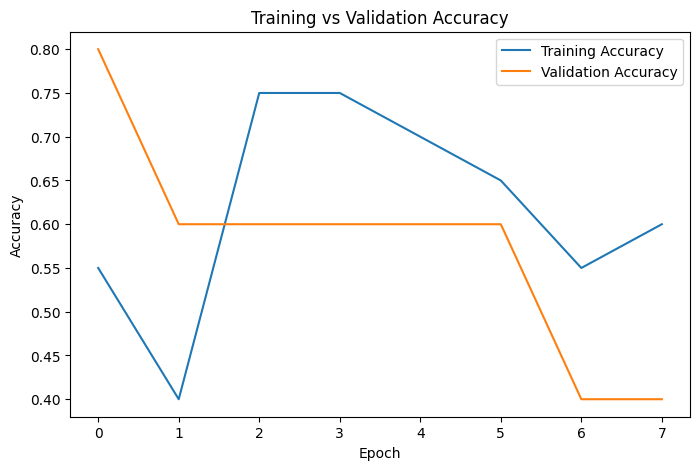

In [4]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping

# =====================================
# Transformer-CNN Hybrid Model
# =====================================

inputs = tf.keras.Input(
    shape=(64,64,64,1)
)

# -------------------------------------
# Conv Block 1
# -------------------------------------

x = layers.Conv3D(
    32,
    (3,3,3),
    activation="relu",
    padding="same"
)(inputs)

x = layers.BatchNormalization()(x)

x = layers.MaxPooling3D(
    (2,2,2)
)(x)

# -------------------------------------
# Conv Block 2
# -------------------------------------

x = layers.Conv3D(
    64,
    (3,3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.MaxPooling3D(
    (2,2,2)
)(x)

# -------------------------------------
# Conv Block 3
# -------------------------------------

x = layers.Conv3D(
    128,
    (3,3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

# -------------------------------------
# Transformer
# -------------------------------------

x = layers.Reshape(
    (-1,128)
)(x)

attention = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x,x)

x = layers.Add()(
    [x, attention]
)

x = layers.LayerNormalization()(x)

# -------------------------------------
# Classification Head
# -------------------------------------

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.5
)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

# -------------------------------------
# Model
# -------------------------------------

model = Model(
    inputs,
    outputs
)

# -------------------------------------
# Compile
# -------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =====================================
# Early Stopping
# =====================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# =====================================
# Training
# =====================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=20,
    batch_size=2,
    callbacks=[early_stop]
)

# =====================================
# Evaluation
# =====================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# =====================================
# Predictions
# =====================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

y_pred = model.predict(
    X_test
)

y_pred = (
    y_pred > 0.5
).astype(int)

# Accuracy

acc = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy Score:")
print(acc)

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# Classification Report

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =====================================
# Accuracy Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()